# Decoding PicoQuantFit Fluorescence TTTR Files (.ptu) and Fitting of Fluorescence Decays

This script deals with decoding of PicoQuant TTTR files (.ptu) produced by HydraHarp V2 and fitting of the fluorescence decays in each image pixel. First, the header section is decoded to gain necessary information for proper decoding of the photon record data and the actual microscope image, i.e. the position in x and y where a particular photon record was made. Second, the photon recond data are read and sorted into a 3D array. This array holds the fluorescence decay curves of each pixel and are subsequently fitted to obtain fluorescence lifetimes.

**In this script, only HydraHarp V2 TTTR data are treated and decoded. However, it can easily be expanded to also cover different PicoQuant TCSPC hardware.**

This script is based on PicoQuants' .ptu decoding example (https://github.com/PicoQuant/PicoQuant-Time-Tagged-File-Format-Demos/blob/master/PTU/Python/Read_PTU.py) and an adaption of that script for the PhasorFLIM application written in JavaScript (https://github.com/Tomkaehst/PhasorFLIM/blob/master/app/filedecoding/PTUReaderBitwise.js).

Furthermore, this Jupyter Notebook serves as interactive sandbox environment and the actual data processing should be done in dedicated Python scripts. 


## PTU File Architecture

*.ptu* files consist of a header and record section. In the header, information about the FLIM system and imaging parameters are stored, which are required in order to reconstruct FLIM images from the single photon data encoded in the record section.
In the following section, the header information is read and stored in a tuple for easier access down the road.

### File Magic

*.ptu* files can be identified and verified by the file magic string encoded in the first eight bytes. It should read ```PQTTTR```. The next eight bytes contain the file version (see ).

After file verification, header tags of different data types are read out. The header end is indicated by "Header_End" and can be searched for to know when to stop decoding it. Header data types are indicated by type code tags in each 48 byte header data piece. It is checked to decide what data type should be extracted from the binary file. To read the photon record data from the following file section, the record type has to be known. This is also encoded in the header section.

In [1]:
%reset -f

# Loading requires Python modules for the *whole* script!
import sys, struct, io, os
import math
import numpy as np
from numba import jit, prange, njit
from scipy.optimize import curve_fit
from scipy import optimize
import scipy.stats as stats
from scipy.integrate import odeint
%matplotlib inline 
import matplotlib.pyplot as plt


# Filepath for test files and creation of a filestream using read-binary
#ptupath = 'qt_app/testData/Capillary_Fluoresceine_DilutionSeries_50nM_1_1.ptu'
#ptupath = '../notebooks/data/HyD_LongTime_Test_12.ptu'
ptupath = '../notebooks/data/TK-E-R51_CMV-mCh-R54_120minNCS_7_1.ptu'
ptureadstream = open(ptupath, 'rb')

# Reading file magic to check if file is PTU file, first 8 byte
filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

# Checking file valiidy by reading file magic and file version
if(filemagic != 'PQTTTR'):
    print('%s is not a .ptu file!' % ptupath)
    ptureadstream.close()
else:
    print('%s is a valid .ptu file... Commencing.' % ptupath)

    
fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
print('File Version: %s' % fileversion)

../notebooks/data/TK-E-R51_CMV-mCh-R54_120minNCS_7_1.ptu is a valid .ptu file... Commencing.
File Version: 1.0.00


In [2]:
# Adjusting figure size of subsequent plots using matplotlib.plt
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 10
fig_size[1] = 8
plt.rcParams["figure.figsize"] = fig_size

print(sys.version,"\n" ,sys.path)

3.7.5 (default, Nov 20 2019, 09:21:52) 
[GCC 9.2.1 20191008] 
 ['/home/agbp/Documents/PhasorFLIM/notebooks', '/usr/lib/python37.zip', '/usr/lib/python3.7', '/usr/lib/python3.7/lib-dynload', '', '/home/agbp/.local/lib/python3.7/site-packages', '/usr/local/lib/python3.7/dist-packages', '/usr/lib/python3/dist-packages', '/home/agbp/.local/lib/python3.7/site-packages/IPython/extensions', '/home/agbp/.ipython']


### PTU File Header & Record Tag Type Definitions

In [3]:
# Definition of header tag types
'''
Each header piece begins with a tag type. It is checked and depending on the type,
different data types have to be extracted.
'''

tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

# Defining record types
'''
Record types of different PicoQuant TCSPC devices. Different TCSPC devices,
require different modes of photon record retrieval. See PicoQuant
documentary for further information. 
Here, only rtHydraHarp2T3 data are considered.
'''
rtPicoHarpT3     = struct.unpack(">i", bytes.fromhex('00010303'))[0]
rtPicoHarpT2     = struct.unpack(">i", bytes.fromhex('00010203'))[0]
rtHydraHarpT3    = struct.unpack(">i", bytes.fromhex('00010304'))[0]
rtHydraHarpT2    = struct.unpack(">i", bytes.fromhex('00010204'))[0]
rtHydraHarp2T3   = struct.unpack(">i", bytes.fromhex('01010304'))[0]
rtHydraHarp2T2   = struct.unpack(">i", bytes.fromhex('01010204'))[0]
rtTimeHarp260NT3 = struct.unpack(">i", bytes.fromhex('00010305'))[0]
rtTimeHarp260NT2 = struct.unpack(">i", bytes.fromhex('00010205'))[0]
rtTimeHarp260PT3 = struct.unpack(">i", bytes.fromhex('00010306'))[0]
rtTimeHarp260PT2 = struct.unpack(">i", bytes.fromhex('00010206'))[0]
rtMultiHarpNT3   = struct.unpack(">i", bytes.fromhex('00010307'))[0]
rtMultiHarpNT2   = struct.unpack(">i", bytes.fromhex('00010207'))[0]

## Decoding Header Information
In the first file segment, information about the measurement are encoded in different data types (see PicoQuant TTTR documententation in GitHub repository above).
Each header piece has 48 bytes. 

- 0:32 holds the tag ID (e.g. filename, image dimensions, ...)
- 32:36 holds the tag index
- 36:40 holds tag data type identifier (see above)
- 40:48 holds actual tag value

The header is read in 48 byte chunks until the header end tag is encounterd. The detected tag data type decides how a header piece is treated. If a string is identified, the tag value variable indicates in how many bytes the string in encoded. After treatment, header chunks are stored in the header_contents dictionary.

In [4]:
## setting up header end string to terminate header decoding in while loop 
headerend_tag = 'Header_End'
reached_headerend = False


# tuple that stores decoded information from header section
header_contents = {}

# decoding header
while(reached_headerend == False):
    headerpiece = ptureadstream.read(48)
    tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
    tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
    tagType = struct.unpack('<i', headerpiece[36:40])[0]
    tagVal = headerpiece[40:48]
    
    if(tagId == headerend_tag):
        reached_headerend = True
        ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
        print('Found Header_End.')
        break
    
    if(tagType == tyEmpty8):
        header_contents['Empty'] =  'Empty'
        
    elif(tagType == tyBool8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyInt8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8):
        value = struct.unpack('<d', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8Array):
        value = struct.unpack("<q", tagVal)[0]
        print('Float array with %d entries' % value / 8)
        
    elif(tagType == tyAnsiString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('latin1').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyWideString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyBinaryBlob):
        value = struct.unpack("<q", tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyBitSet64):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyColor8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  "{0:#0{1}x}".format(value,18)
        
    elif(tagType == tyBinaryBlob):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value

    elif(tagType == tyTDateTime):
        print(' ')
        
    else:
        continue
        #print('Unknown header tag type. Ignored.')
        
    
headerend_bitoffset = ptureadstream.tell() # Needed to quickly jump to photon records instead of header
    
print('Finished decoding header.')
print(header_contents)

 
Found Header_End.
Finished decoding header.
{'File_GUID': '{4D151AD3-2FF3-4E11-8313-6921DF5CB49C}', '$StartedByRemoteInterface': -1, 'Measurement_SubMode': 3, 'File_Comment': 'LAS X 2.0.1.14392\r\nU2OS, transfected with TK-EGFP-RAD51 and CMV-mCherry-RAD54 on Saturday, synchronized via double thymidine block, 120 min NCS, DIFFERENT CELLS THAN BEFORE!\r\nPinhole: 58.69 µm\r\nObjective: HC FLUOTAR L 25.0 WATER\r\nImage Format: 512 x 512\r\nScan Speed: 100 Hz\r\nZoom: 6.7\r\nFrame Average: 250\r\nDirection: Unidirectional\r\n\r\nWLL\r\n LaserLine 488: 2.0\r\n Laser Shutter: Open\r\n\r\nLaser (WLL, WLL) On 70.0\r\nLaser (Argon, visible) Off 0.0\r\nLaser (IR, MP) On\r\nLaser (IR2, FSOPO) On\r\nMFP Filter: Substrate \r\nPolarization Filter: NF 488\r\nNotch Filter: Empty\r\nX1-Port: Mirror \r\nScan Mode: xyz\r\nZPosition: 0.00 µm\r\nSpectral detection range\r\nSP PMT 1: 500...550nm \r\nSP PMT 2: 605...655nm \r\n\r\nFLIM Detector: Intern\r\nAcquisition Mode: Frame Repetition 250\r\n', 'TTResu

The releveant header information is now copied into a new structure for convinient access.
In order to reconstruct the FLIM image, several value are required

- Filename: Filename
- Comment: String containing user comments
- TTResultsFormat_TTTRRecType: Type of the photon records i.e. which device was used
- TTResultFormat_BitsPerRecord: Number of bits in a photon record
- ReqHdr_SpatialResolution: Width of a pixel in µm
- ImgHdr_PixX: How many pixels in X?
- ImgHdr_PixY: How many pixels in Y?
- MeasDesc_GlobalResolution: time resolution of measurement
- HW_BaseResolution: Principal time resolution of device
- MeasDesc_Resolution: TCSPC resolution, also obtained by BaseResolution * BinningFactor
- MeasDesc_BinningFactor: Binning factor
- TTResult_SyncRate: Laser pulse / Sync rate of measurement
- TTResult_NumberOfRecords: How many 32 bit records in file?

In [5]:
FLIMInfo = {
    'Filename' : header_contents['$Filename'],
    'Comment': header_contents['$Comment'],
    'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
    'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
    'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
    'PixelsX' : header_contents['ImgHdr_PixX'],
    'PixelsY' : header_contents['ImgHdr_PixY'],
    'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
    'BaseResolution' : header_contents['HW_BaseResolution'],
    'Resolution' : header_contents['MeasDesc_Resolution'],
    'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
    'SyncRate' : header_contents['TTResult_SyncRate'],
    'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
}
FLIMInfo

{'Filename': 'TK-E-R51_CMV-mCh-R54_120minNCS_7_1',
 'Comment': 'LAS X 2.0.1.14392\nU2OS, transfected with TK-EGFP-RAD51 and CMV-mCherry-RAD54 on Saturday, synchronized via double thymidine block, 120 min NCS, DIFFERENT CELLS THAN BEFORE!\nPinhole: 58.69 µm\nObjective: HC FLUOTAR L 25.0 WATER\nImage Format: 512 x 512\nScan Speed: 100 Hz\nZoom: 6.7\nFrame Average: 250\nDirection: Unidirectional\n\nWLL\n LaserLine 488: 2.0\n Laser Shutter: Open\n\nLaser (WLL, WLL) On 70.0\nLaser (Argon, visible) Off 0.0\nLaser (IR, MP) On\nLaser (IR2, FSOPO) On\nMFP Filter: Substrate \nPolarization Filter: NF 488\nNotch Filter: Empty\nX1-Port: Mirror \nScan Mode: xyz\nZPosition: 0.00 µm\nSpectral detection range\nSP PMT 1: 500...550nm \nSP PMT 2: 605...655nm \n\nFLIM Detector: Intern\nAcquisition Mode: Frame Repetition 250\n',
 'RecordType': 16843524,
 'BitsPerRecord': 32,
 'PixelResolution': 1.2814653871373594e-07,
 'PixelsX': 512,
 'PixelsY': 512,
 'GlobalResolution': 5.1414093219920696e-08,
 'BaseResol

## Decoding Photon Records
After header reading, we have sufficient information to decode the photon data from the ```.ptu``` file. **Because in this script, only HydraHarp V2 TTTR data are decoded**, only this record type is considered.

### Photon Data Architecture
A HydraHarp V2 TTTR record has 32 bits and encodes three types of information:
- marker
    - Indicates channel in which photon was detected, of regular photon record occured
    - Indicates several special records
        - macro time overflow
        - frame and line start or stop
- macro time
    - Experiment time in s
- nano time
    - time of photon arrival realtive to laser pulse


#### Meaning of Marker Events

The marker stream consists of two elements: the special bit and the channel bits. The special bit is the first bit of each 32 bit photon record. When it is set it indicates that the record is not a photon, but a system marker event: line start (65 = 1000001), line stop (67 = 1000010), or an macrotime clock overflow (127 = 1111111) [frame start and stop are not encoded in our setup].
When the special bit is not set, the channel bits indicate the channel number in which the photon event was registered.
In the case of an macrotime bit overflow, the nanotime bits encode the number of times an overflow has occured so far (comment to self: check this again in the documentary). This is required to calculate the real macrotime of the experiment.

In [6]:
ptureadstream.close()

### Rewriting *.ptu* Decoding with NumPy 
Only photon record section for now. Byte offset until photon records saved above after ```Header_End``` tag has been detected.

In [7]:
@jit(nopython=True, cache=True)
def treatOverflows(recordarray, macrotimefactor):
    '''
    Function treatOverflows(
    recordarray: 4 x numRec NumPy array holding raw 32 bit photon records in ['record']
    macrotimefactor: multiplication factor for mactotime clock to recover real experiment macrotime
    )
    Output is recordarray, but with populated ['macrotime'] row
    
    Takes whole record array and recovers real macrotime from raw photon TTTR data by adding
    number of macrotime clock overflows. See PicoQuant PTU documentary for further details and explanation.
    '''
    
    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor += overflow_period * \
                (record['record'] & (2**10 - 1))

        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10-1)) * macrotimefactor
            
    return(recordarray)

In [8]:
## Trying to use NumPy for binary decoding and processing

## Data type definition for recordarray
### Data types are chosen, so that they use the least space possible
recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8),
                              ('nanotime', np.float64), ('macrotime', np.float64)])


# Preallocating array with decoded raw FLIM data
recordarray = np.zeros(
        shape=FLIMInfo['NumberOfRecords'] - 1, dtype=recordBitType)

# Factors required to recover real macro and nanotimes from raw photon data stream
macroMultFactor = FLIMInfo['GlobalResolution']
nanoMultFactor = FLIMInfo['Resolution'] * 1e9


# Opening .ptu file and shoveling it into UInt32 section of preallocated array
with open(ptupath, 'rb') as file:
    file.seek(headerend_bitoffset)
    recordarray[:]['record'] = np.fromfile(file, dtype=np.uint32)
    file.close()
    
# Recover marker signals and nanotimes of photon events
recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
recordarray[:]['nanotime'] = (np.right_shift(recordarray[:]['record'], 10) & 32767) * nanoMultFactor


# Recover macrotimes and treat overflows
recordarray = treatOverflows(recordarray, macroMultFactor)

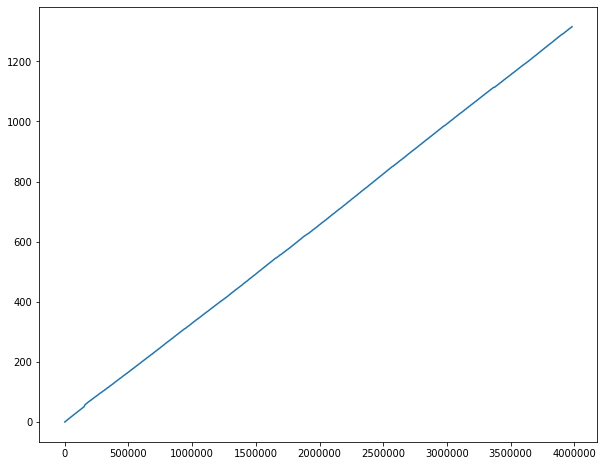

In [9]:
# Checking if macrotime has been properly corrected. If so, it increases over number of events.
plt.plot(recordarray['macrotime'])
plt.show()

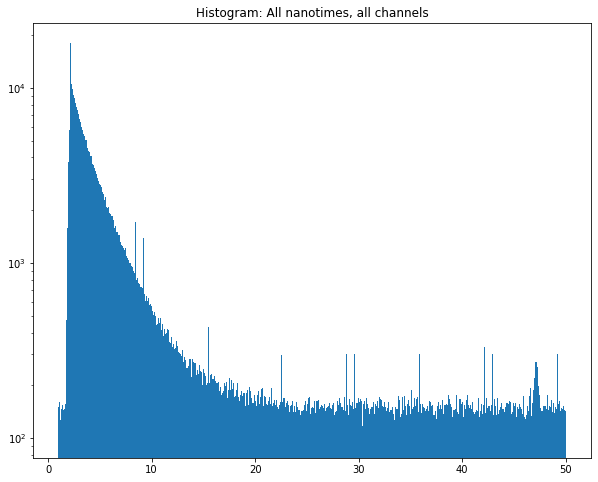

In [10]:
plt.hist(recordarray['nanotime'], bins=3000, range = (1, 50), log = "y")
plt.title("Histogram: All nanotimes, all channels")
plt.show()

## Reconstructing Image from Data Stream

In [11]:
@jit(nopython=True)
def countLines(recordarray):
    '''
    Function: countLines(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    )
    
    - Counts number of line start (marker == 65) and line stop (marker == 66) events in raw photon data
    - Purpose: check data integrity
    '''

    numLinesStart = np.sum(recordarray['marker'] == 65)
    numLinesStop = np.sum(recordarray['marker'] == 66)
    
    if(numLinesStart != numLinesStop):
        print("Line start and stop numbers not equal. Corrupted file?")
    
    return numLinesStart

In [12]:
@jit(nopython=True, cache=True)
def checkChannelAvailability(recordarray):

    channelList = []

    if(np.any(recordarray['marker'] == 0)):
        channelList.append(0)

    if(np.any(recordarray['marker'] == 1)):
        channelList.append(1)

    if(np.any(recordarray['marker'] == 2)):
        channelList.append(2)

    if(np.any(recordarray['marker'] == 3)):
        channelList.append(3)

    print("Detected channels: ", channelList)

    return channelList

In [13]:
FLIMInfo['channelList'] = checkChannelAvailability(recordarray)

Detected channels:  [0, 1]


In [14]:
FLIMInfo['LinesInFile'] = countLines(recordarray)

In [15]:
FLIMInfo

{'Filename': 'TK-E-R51_CMV-mCh-R54_120minNCS_7_1',
 'Comment': 'LAS X 2.0.1.14392\nU2OS, transfected with TK-EGFP-RAD51 and CMV-mCherry-RAD54 on Saturday, synchronized via double thymidine block, 120 min NCS, DIFFERENT CELLS THAN BEFORE!\nPinhole: 58.69 µm\nObjective: HC FLUOTAR L 25.0 WATER\nImage Format: 512 x 512\nScan Speed: 100 Hz\nZoom: 6.7\nFrame Average: 250\nDirection: Unidirectional\n\nWLL\n LaserLine 488: 2.0\n Laser Shutter: Open\n\nLaser (WLL, WLL) On 70.0\nLaser (Argon, visible) Off 0.0\nLaser (IR, MP) On\nLaser (IR2, FSOPO) On\nMFP Filter: Substrate \nPolarization Filter: NF 488\nNotch Filter: Empty\nX1-Port: Mirror \nScan Mode: xyz\nZPosition: 0.00 µm\nSpectral detection range\nSP PMT 1: 500...550nm \nSP PMT 2: 605...655nm \n\nFLIM Detector: Intern\nAcquisition Mode: Frame Repetition 250\n',
 'RecordType': 16843524,
 'BitsPerRecord': 32,
 'PixelResolution': 1.2814653871373594e-07,
 'PixelsX': 512,
 'PixelsY': 512,
 'GlobalResolution': 5.1414093219920696e-08,
 'BaseResol

In [16]:
@jit(nopython=True, cache=True)
def buildFLIMArray(recordarray, channel, linesinfile, pixelsx, pixelsy, globRes, timeRes, spatialBinning, temporalBinning):
    '''
    buildFLIMArray(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    - channel: int; which channel to reconstruct the flimarray from
    - pixelsx: original image dimension in X, stored in FLIMInfo
    - pixelsy: original image dimension in Y, stored in FLIMInfo
    - globRes: global measurment of nanotime, stored in FLIMInfo, in ns, 51 ns for 20 MHz laser pulse frequency
    - timeRes: nanotime resolution of TCSPC device, in ps
    - spatialBinning: user-defined binning factor of image, calculated as 2**factor
    - temporalBinning: user-defined binning factor for fluorescence decay histogram
    )
    '''

    eventCounter = 0  # Keeps track of photon / marker events while looping through data
    lineCounter = 0  # Stores current scan line numbers
    frameCounter = 0  # Stores current frame number
    # How many frames are in the image; assume square format
    framesInFile = linesinfile / pixelsx
    # Number of TCSPC bins based on time between pulses and TCSPC time resolution
    decayBins = math.ceil((globRes / timeRes)/(2**temporalBinning))
    globalResolution = globRes * 10E8  # time between pulses in ns
    timeResolution = timeRes * 10E9  # TCSPC time resolution in nss

    binningFactor = 2**spatialBinning

    lineStart = 0
    lineStop = 0
    pixelTime = 0  # Tmp variable for storing time/pixel when line start and stop macro times are determined; needed to assign photons to y pixels in a line

    # Set to True when last scan line was evaluated and frameCounter >= framesInFile
    lastLine = False
    # Set to True when line start marker is found (= 65), starts photon assignments to y-pixels in a line (x); set to False when line stop marker is found (=66)
    lineActive = False

    # List storing photon macrotimes when line is active to determine y-pixel position of photon
    tmpEvents = [np.float64(x) for x in range(0)]
    # List storing photon nanotimes to assign to 3D-FLIM array in x-y position
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0  # Holds marker value for one loop iteration
    tmpMacro = 0  # Holds macrotime value for one loop iteration
    tmpNanotime = 0  # Holds nanotime value for one loop iteration
    diff = 0  # Stores difference between photon macro time and line start to determine photon y-position
    # Count out-of-range photons (photons with macrotime below or above line time difference)
    oorPhotons = 0

    nPixelX = int(pixelsx / binningFactor)
    nPixelY = int(pixelsy / binningFactor)

    pixelIDX = 0  # Current x position in image
    pixelIDY = 0  # Current y position in image

    flimarray = np.zeros((nPixelX, nPixelY, decayBins), dtype=np.uint16)
    # 2D array for intensity image
    intensityImage = np.zeros((nPixelX, nPixelY), dtype=np.uint16)

    while(lastLine == False):
        tmpMarker = recordarray['marker'][eventCounter]

        if(tmpMarker == 65):  # Event is line start marker
            lineActive = True  # Starting line evaluation (next while loop)
            # Store line start time
            lineStart = recordarray['macrotime'][eventCounter]
            eventCounter += 1
            continue  # Skip this loop iteration

        if(tmpMarker == 0 or tmpMarker == 1 or tmpMarker == 2 or tmpMarker == 3):
            oorPhotons += 1

        while(lineActive == True):
            tmpMarker = recordarray['marker'][eventCounter]
            tmpMacro = recordarray['macrotime'][eventCounter]
            tmpNanotime = recordarray['nanotime'][eventCounter]

            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / (nPixelY)

                # Build intensity image and FLIM array from photon macro times
                for i in range(0, len(tmpEvents)):
                    diff = tmpEvents[i] - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    binID = math.floor((tmpNano[i]/globalResolution)*decayBins) - 1

                    if(pixelIDY < 0 or pixelIDY > (nPixelY - 1)):
                        #oorPhotons = oorPhotons + 1
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (nPixelY - 1)):
                            pixelIDY = nPixelY - 1

                    intensityImage[math.floor(pixelIDX)][pixelIDY] += 1
                    flimarray[math.floor(pixelIDX)][pixelIDY][binID] += 1

                pixelIDX = pixelIDX + (1/binningFactor)
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]

            eventCounter += 1

        if(lineCounter > (pixelsx - 1)):
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0

        if(frameCounter >= framesInFile):
            lastLine = True

        eventCounter += 1

    print("Assigned photons to pixels.\n",
          (oorPhotons / np.sum(intensityImage))*100,
          "% of photons were out of range... Total:", oorPhotons, "of", np.sum(intensityImage), "photons.")

    return flimarray, intensityImage


In [17]:
@jit(nopython=True, cache=True, parallel = True)
def buildFLIMArray_parallel(recordarray, channel, linesinfile, pixelsx, pixelsy, globRes, timeRes, spatialBinning, temporalBinning):
    '''
    buildFLIMArray(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    - channel: int; which channel to reconstruct the flimarray from
    - pixelsx: original image dimension in X, stored in FLIMInfo
    - pixelsy: original image dimension in Y, stored in FLIMInfo
    - globRes: global measurment of nanotime, stored in FLIMInfo, in ns, 51 ns for 20 MHz laser pulse frequency
    - timeRes: nanotime resolution of TCSPC device, in ps
    - spatialBinning: user-defined binning factor of image, calculated as 2**factor
    - temporalBinning: user-defined binning factor for fluorescence decay histogram
    )
    '''

    eventCounter = 0  # Keeps track of photon / marker events while looping through data
    lineCounter = 0  # Stores current scan line numbers
    frameCounter = 0  # Stores current frame number
    # How many frames are in the image; assume square format
    framesInFile = linesinfile / pixelsx
    # Number of TCSPC bins based on time between pulses and TCSPC time resolution
    decayBins = math.ceil((globRes / timeRes)/(2**temporalBinning))
    globalResolution = globRes * 10E8  # time between pulses in ns
    timeResolution = timeRes * 10E9  # TCSPC time resolution in nss

    binningFactor = 2**spatialBinning

    lineStart = 0
    lineStop = 0
    pixelTime = 0  # Tmp variable for storing time/pixel when line start and stop macro times are determined; needed to assign photons to y pixels in a line

    # Set to True when last scan line was evaluated and frameCounter >= framesInFile
    lastLine = False
    # Set to True when line start marker is found (= 65), starts photon assignments to y-pixels in a line (x); set to False when line stop marker is found (=66)
    lineActive = False

    # List storing photon macrotimes when line is active to determine y-pixel position of photon
    tmpEvents = [np.float64(x) for x in range(0)]
    # List storing photon nanotimes to assign to 3D-FLIM array in x-y position
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0  # Holds marker value for one loop iteration
    tmpMacro = 0  # Holds macrotime value for one loop iteration
    tmpNanotime = 0  # Holds nanotime value for one loop iteration
    diff = 0  # Stores difference between photon macro time and line start to determine photon y-position
    # Count out-of-range photons (photons with macrotime below or above line time difference)
    oorPhotons = 0

    nPixelX = int(pixelsx / binningFactor)
    nPixelY = int(pixelsy / binningFactor)

    pixelIDX = 0  # Current x position in image
    pixelIDY = 0  # Current y position in image

    flimarray = np.zeros((nPixelX, nPixelY, decayBins), dtype=np.uint16)
    # 2D array for intensity image
    intensityImage = np.zeros((nPixelX, nPixelY), dtype=np.uint16)

    while(lastLine == False):
        tmpMarker = recordarray['marker'][eventCounter]

        if(tmpMarker == 65):  # Event is line start marker
            lineActive = True  # Starting line evaluation (next while loop)
            # Store line start time
            lineStart = recordarray['macrotime'][eventCounter]
            eventCounter += 1
            continue  # Skip this loop iteration

        if(tmpMarker == 0 or tmpMarker == 1 or tmpMarker == 2 or tmpMarker == 3):
            oorPhotons += 1

        while(lineActive == True):
            tmpMarker = recordarray['marker'][eventCounter]
            tmpMacro = recordarray['macrotime'][eventCounter]
            tmpNanotime = recordarray['nanotime'][eventCounter]

            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / (nPixelY)

                # Build intensity image and FLIM array from photon macro times
                for i in prange(0, len(tmpEvents)):
                    diff = tmpEvents[i] - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    binID = math.floor((tmpNano[i]/globalResolution)*decayBins) - 1

                    if(pixelIDY < 0 or pixelIDY > (nPixelY - 1)):
                        #oorPhotons = oorPhotons + 1
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (nPixelY - 1)):
                            pixelIDY = nPixelY - 1

                    intensityImage[math.floor(pixelIDX)][pixelIDY] += 1
                    flimarray[math.floor(pixelIDX)][pixelIDY][binID] += 1

                pixelIDX = pixelIDX + (1/binningFactor)
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]

            eventCounter += 1

        if(lineCounter > (pixelsx - 1)):
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0

        if(frameCounter >= framesInFile):
            lastLine = True

        eventCounter += 1

    print("Assigned photons to pixels.\n",
          (oorPhotons / np.sum(intensityImage))*100,
          "% of photons were out of range... Total:", oorPhotons, "of", np.sum(intensityImage), "photons.")

    return flimarray, intensityImage


In [18]:
flimarray, intimage = buildFLIMArray(recordarray,
                                              0,
                                              FLIMInfo['LinesInFile'],
                                              FLIMInfo['PixelsX'],
                                              FLIMInfo['PixelsY'],
                                              FLIMInfo['GlobalResolution'],
                                              FLIMInfo['Resolution'],
                                              0,
                                              0)


recordarray = None # dereferencing recordarray for garbage collection; in the future: ptu processing via data stream!

Assigned photons to pixels.
 34.14038969716709 % of photons were out of range... Total: 406709 of 1191284 photons.


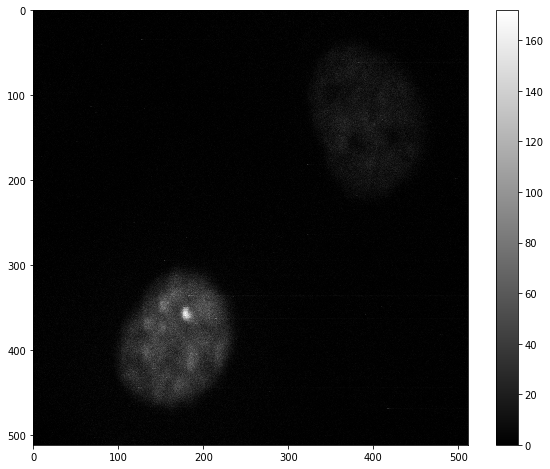

In [19]:
plt.imshow(intimage, cmap = "gray")
plt.colorbar()
plt.show()

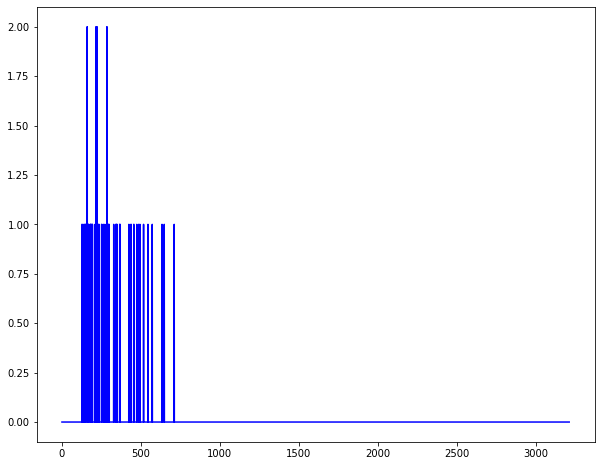

In [21]:
plt.plot(flimarray[350][175][:], 'b-')
#plt.yscale("log")
plt.show()

## Data Fitting
The functions above produced two arrays, one holding the intensity image (2D, intImg) and one holding the fluorescence decays (3D, flimarray).

As a first attempt, the fluorescence lifetimes of the image are determined by tail fitting. Iterative reconvolution and model-based fitting is implemented bases upon that.

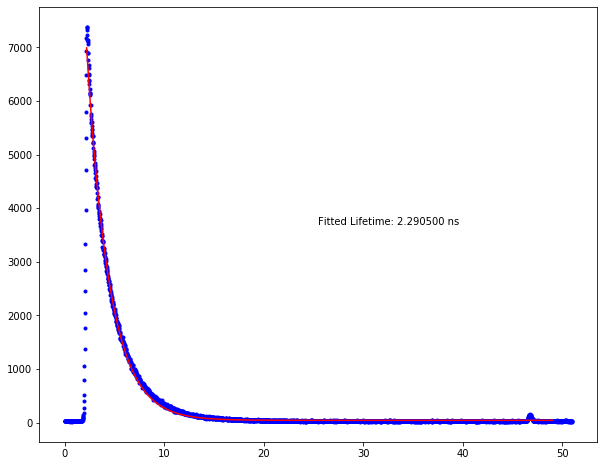

2.2905

In [22]:
# Simple exponential decay
def expDecay(x, a, b, tau):
    return(a * np.exp(-x/tau) + b)

def globalTailFit(flimarray, FLIMInfo, showPlot = True):
      # There's definitely a smarter way to do this.
    overallDecay = np.sum(np.sum(flimarray, axis=0), axis=0)
    #overallDecay = np.sum(np.where())
    xaxis = np.linspace(
        0, round(FLIMInfo['GlobalResolution']*10E8), flimarray.shape[2])
    maxVal = np.where(overallDecay == max(overallDecay))[0][0]
    endOfData = overallDecay.size - 100
    plt.plot(xaxis, overallDecay, 'b.')
    tau_fit, tau_cov = curve_fit(
        expDecay, xaxis[maxVal:endOfData-20], overallDecay[maxVal:endOfData-20], p0=(max(overallDecay), 0, 5))

    lifetime = round(tau_fit[2], 4)

    if(showPlot == True):
        plt.text(1/2*max(xaxis), max(overallDecay)/2, "Fitted Lifetime: %f ns" % lifetime)
        plt.plot(xaxis[maxVal:endOfData-20],
             expDecay(xaxis, *tau_fit)[maxVal:endOfData-20], 'r-')

        plt.show()

    return(lifetime)

globalTailFit(flimarray, FLIMInfo, showPlot = True)

### Pixel-wise Fitting (Paralellized with Numba)




[1996.31471708 2513.81660581   29.75705902]
[[ 2.75691317e+01 -3.43795532e+01 -5.73903284e-02]
 [-3.43795532e+01  1.04516650e+02 -2.33299230e+00]
 [-5.73903284e-02 -2.33299230e+00  4.77669274e-01]]

SciPy ChiSq:	 985.0570570711429 	p value: 2.5604086731118254e-70
chisq =		 985.0570570711429   3.137124385576888 
df =		 316


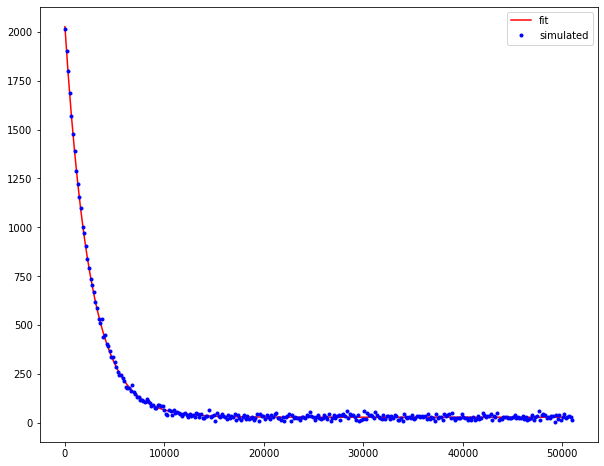

In [23]:
def expDecay_lm(t, N0, tau, offset):
    y = N0 * np.exp(-t/tau) + offset
    return(y)


T = 51000
dt = 160
N0 = 2000
tau = 2500
offset = 10
stdev = 5

# Create the artificial dataset
t = np.linspace(0, T, T/dt)
N = expDecay_lm(t, N0, tau, stdev)
Nfluct = stdev * np.random.poisson(stdev, size = len(t))
N += Nfluct
sig = np.zeros(len(t)) + stdev

# Fit the curve
start = (20000, 2400, 0)
#popt, pcov = curve_fit(expDecay_lm, t, N, sigma = sig, p0 = start, absolute_sigma=True, method = 'lm')
popt, pcov = curve_fit(expDecay_lm, t, N, p0 = start, method = 'lm')
print(popt)
print(pcov)

# Compute chi square
Nexp = expDecay_lm(t, *popt)
chisq = np.sum(((N - Nexp)**2)/Nexp)#np.sum(((N - Nexp))/Nexp)**2
chisq_scipy = stats.chisquare(N, Nexp, 3)

chisq_red = chisq/(len(N) - 4)
df = len(t) - 2

print('\nSciPy ChiSq:\t', chisq_scipy[0], "\tp value:", chisq_scipy[1])
print('chisq =\t\t',chisq, " ", chisq_red,'\ndf =\t\t', df)
# Plot the data with error bars along with the fit result
#plt.errorbar(t, N, yerr=sig, fmt = 'o', label='"data"')
plt.plot(t, Nexp, 'r-', label = 'fit')
plt.plot(t, N, 'b.', label = 'simulated')
#plt.yscale('log')
plt.legend()
plt.show()

In [24]:
from numba import prange, njit # njit is short-hand for @jit(nopython=True)

@jit(nopython = True)
def expDecay(x, a, b, tau):
    return(a * np.exp(-x/tau) + b)

#@jit(nopython = True)
def pixelwiseSimpleDecay(flimarray, photonthreshold, rightcutoff, globRes):
    '''
        Function: pixelwiseSimpleDecay(
            - flimarray: 3D array x-y-ns holding fluorescence decays for each image pixel
            - photonthreshold: number of photons in pixel required to start fitting
            - rightcuttoff: how much data of decay to exclude from the right side of the curve
            - globRes: FLIMInfo['GlobalResolution'], required to reconstruct time axis with correct time (in ns)
        )
    '''
    numDecaysX = flimarray.shape[0]
    numDecaysY = flimarray.shape[1]
    
    lifetimeImage = np.zeros((numDecaysX, numDecaysY), dtype = np.float64)
    tau_fit = []
    tau_cov = []
    
    for x in range(numDecaysX):
        for y in range(numDecaysY):
            if(flimarray[x][y][:].sum() > photonthreshold):
                xaxis = np.linspace(0, round(globRes*10E8), flimarray.shape[2])
                maxVal = np.where(flimarray[x][y] == max(flimarray[x][y]))[0][0]
                endOfData = flimarray[x][y].size - rightcutoff
                try:
                    tau_fit = curve_fit(expDecay, xaxis[maxVal:endOfData], flimarray[x][y][maxVal:endOfData])[0]
                    lifetimeImage[x][y] = tau_fit[2]
                except:
                    lifetimeImage[x][y] = 100
            else:
                lifetimeImage[x][y] = 100
        
    
    return(lifetimeImage)

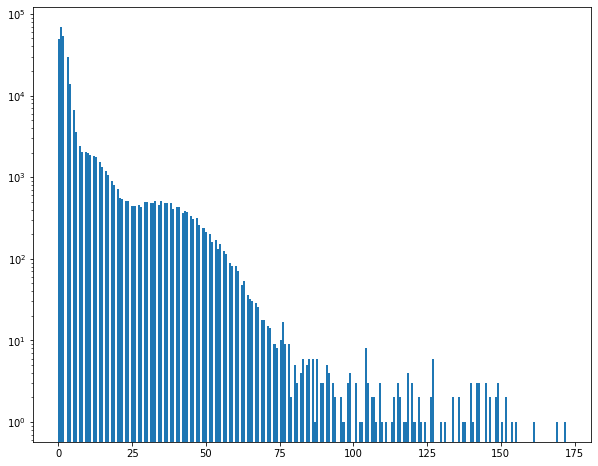

In [25]:
# Show histogram of pixel-photon count
photonDistribution = plt.hist(np.reshape(intimage, (intimage.size)), bins = 250, log = True)
plt.show()

In [30]:
fittedImage = pixelwiseSimpleDecay(flimarray, 50, 10, FLIMInfo['GlobalResolution'])

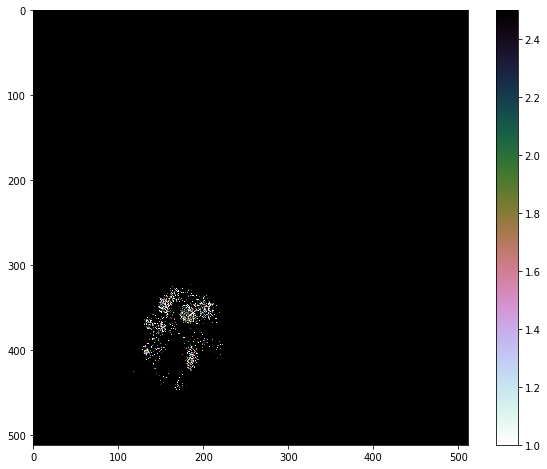

In [171]:
plt.imshow(fittedImage, cmap = "cubehelix_r")
plt.clim(1, 2.5)
plt.colorbar()
plt.show()

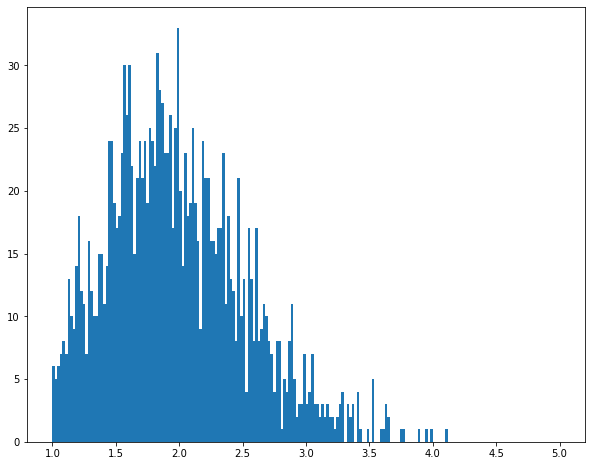

In [32]:
fittedHist = plt.hist(np.reshape(fittedImage, (fittedImage.size)), range = (1, 5), bins = 200, density = False)
plt.show()

## Reconvolutional Fitting

Monoexponential decay:


$$N(t) = N_0 e^{-t/\tau}$$

In [46]:
#%reset -f
import numpy as np
import matplotlib.pyplot as plt
import skimage

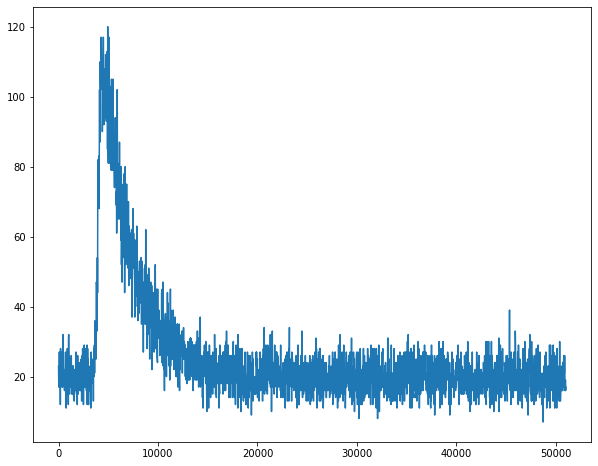

In [305]:
def gauss_laser(t, mu, sigma):
    y = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(t-mu)**2/(2*sigma)**2)
    return(y)

def expDecay(t, N0, tau):
    return(N0 * np.exp(-t/tau))

def convolutedDecay(t, offset, amp1, tau1, IRFmu, IRFsigma, fitting = False):
    IRF = gauss_laser(t, IRFmu, IRFsigma)
    decay = expDecay(t, amp1, tau1)
    
    convolvedSignal = np.convolve(IRF, decay, mode = 'full')[0:n]
    
    if(fitting == False): # Set fitting to True to suppress addition of Poisson noise, set True when simulating a decay
        convolvedSignal = addPoissonNoise(convolvedSignal, offset)
    else:
        convolvedSignal += offset
    
    return(convolvedSignal)

def addPoissonNoise(decay, offset):
    decay = np.random.poisson(decay, len(decay))
    decay += np.random.poisson(offset, len(decay))
    
    return(decay)
    

# Objective function
def residuals(para_est, t, data, weighted = True):
    if(weighted == True):
        weights = 1/np.sqrt(data)
        resids = (data - convolutedDecay(t, *para_est, True))**2 * weights
    else:
        resids = (data - convolutedDecay(t, *para_est, True))**2
        
    return(resids)


T = 51000
dt = 20
n = int(T/dt)
noise = 0
time = np.linspace(0, T, n)
xdata = time


# Simulation parameters
para_sim = (
    20, # offset
    1500, # Amplitude 1
    3000, # tau 1
    4000, # Laser mu / shift
    150 # Laser sigma
)

# Initial guessing and Data Fitting
para_start = (
    1, # offset
    5000, # Amplitude 1
    2000, # tau 1
    3000, # Laser mu / shift
    300 # Laser sigma
)

para_names = (
    "offset",
    "amp1",
    "tau1",
    "IRFmu",
    "IRFsig"
)


# Simulating data and adding Poisson noise
simulated = convolutedDecay(time, *para_sim, fitting = False)



plt.plot(time, simulated)
#plt.yscale('log')
plt.show()

`ftol` termination condition is satisfied.
Function evaluations 22, initial cost 1.6149e+09, final cost 1.0039e+05, first-order optimality 1.93e-02.


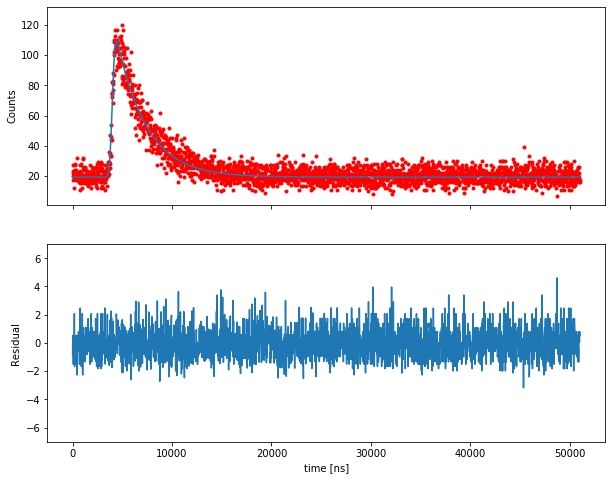

	Input Parameters	 Fitted Parameters
---------------------------------------------
offset 		 20 			 19.188696577496113
amp1 		 1500 			 1511.7596483208804
tau1 		 3000 			 2956.9154410080464
IRFmu 		 4000 			 4010.616925479111
IRFsig 		 150 			 153.29723459768343


Chi-Sq (abs. / red.):	 2690.095782164444 	 1.057012095153023
Chi-Sq (SciPy):		 2690.095782164444 	 1.057012095153023  (p-value: 0.021716612228810717 )



In [306]:

#para_opt, para_cov = optimize.leastsq(residuals, para_start)
para_opt = optimize.least_squares(residuals,
                                  para_start,
                                  method = 'trf',
                                  loss = 'linear',
                                  ftol = 1e-9, # Is default of least_squares()
                                  verbose = 1,
                                  args = (time, simulated, True))

fitted_curve = convolutedDecay(time, *para_opt['x'], True)


fig, ax = plt.subplots(2, 1, sharex = True)
ax[0].plot(time, simulated, 'r.')
ax[0].plot(time, fitted_curve)
ax[0].set( ylim = (1, max(simulated)*1.1), ylabel = 'Counts')
ax[1].plot(time, (fitted_curve - simulated)*1/np.sqrt(simulated))
ax[1].set(xlabel = 'time [ns]', ylabel = 'Residual', ylim = (-7, 7))
plt.savefig('../notebooks/monoFit.pdf', format = 'pdf')
plt.show()

print("\tInput Parameters\t Fitted Parameters")
print("---------------------------------------------")
for i in range(0, len(para_names)):
    print(para_names[i],"\t\t", para_sim[i], "\t\t\t", para_opt['x'][i])


# Chi-Squared
chisq = np.sum(((simulated - fitted_curve)**2)/fitted_curve)
chisq_scipy = stats.chisquare(simulated, fitted_curve, len(para_start))

chisq_red = chisq/(len(simulated) - len(para_start))
df = len(simulated) - len(para_start)

print("\n")
print("Chi-Sq (abs. / red.):\t", chisq, "\t", chisq_red)
print("Chi-Sq (SciPy):\t\t", chisq_scipy[0], "\t", chisq_scipy[0]/df, " (p-value:", chisq_scipy[1], ")\n")

## 

## Fitting with a System of ODEs 👌
We're simulation a donor-accptor system of the form

$$\frac{dD_1}{dt} = - \frac{dD_0}{dt} = -(k_{f_D} + k_{r_{DA}})D_1 + \phi_D L(t)D_0$$

$$\frac{dA_1}{dt} = - \frac{dA_0}{dt} = -k_{f_A}A_1 + k_{r_{DA}}D_1$$

$$L(t) = \frac{1}{\sqrt{2 \pi} \sigma} e^{-\Big( \frac{(x - \mu)}{\sigma}\Big)^2}$$

The simulated system of differential equations will be fitted to measured data using the Levenberg-Marquardt algorithm. 

**Important**:

- scipy.integrate.odeint varies the step size, always include the hmax argument and set it to dt, so that the maximal step size does not exceed the $dt$ of the simulation; results in problems when the gauss pulse starts

In [2]:
# Importing required modules and setting up matplotlib
from scipy.integrate import odeint
import scipy.optimize as optimize
from lmfit import minimize, Parameter, Parameters, report_fit
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

In [3]:
def da_flim_ODE(y, t, pars):
    '''
        da_flim_ode(y, t, pars) - Function
        
        Description:
            - function defining a system of differential equations for a donor-acceptor FRET-FLIM system
            - intended to be used with eval_ode() function, which calls scipy.odeint for numerical integration
        Input Arguments:
            - y: Vector holding the initial values for all involved species (here D0, D1, A0, and A1)
            - t: time vector generated by numpy.linspace (tStart, tEnd, tSteps = (tEnd-tStart)/dt)
            - pars: vector or Parameters() object (from lmfit.Parameters) with simulation parameters
                pars[0]: kf_D - donor decay constant (1/tau)
                pars[1]: k_r - transfer rate
                pars[2]: kf_A - acceptor decay constant
                pars[3]: sigma - Gauss pulse width in time (in ps), FWHM = 2.3*sigma
                pars[4]: mu - mean of Gauss pulse (in ps)
        Returned:
            - array of four values (dD0, dD1, dA0, dA1) of current integration step
    '''
    try:
        kf_D = pars['kf_D'].value
        k_r = pars['k_r'].value
        kf_A = pars['kf_A'].value
        sigma = pars['sigma'].value
        mu = pars['mu'].value
        offset = pars['offset'].value
        #y = [pars['D0'].value, pars['D1'].value, pars['A0'].value, pars['A1'].value]
        #t = t[0]
    except:
            kf_D, k_r, kf_A, sigma, mu = pars
            t = t
            
    def gauss_laser(t):
        out = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5 * ((t - mu) / sigma)**2)
        return(float(out))
        
    
    dD1 = -kf_D*y[1] - k_r*y[1] + gauss_laser(t)*y[0]
    dD0 = -dD1
    dA1 = -kf_A*y[3] + k_r*y[1]
    dA0 = -dA1
    return([dD0, dD1, dA0, dA1])


def eval_ode(y, t, pars):
    '''
        eval_ode(y, t, pars)  Function
        
        Description:
            - performs numerical integration of da_flim_ode() using scipy.odeint given y0, time axis, and parameters
        Input Arguments:
            - y: Vector holding the initial values for all involved species (here D0, D1, A0, and A1)
            - t: time vector generated by numpy.linspace (tStart, tEnd, tSteps = (tEnd-tStart)/dt)
            - pars: vector or Parameters() object (from lmfit.Parameters) with simulation parameters
                pars[0]: kf_D - donor decay constant (1/tau)
                pars[1]: k_r - transfer rate
                pars[2]: kf_A - acceptor decay constant
                pars[3]: sigma - Gauss pulse width in time (in ps), FWHM = 2.3*sigma
                pars[4]: mu - mean of Gauss pulse (in ps)
                pars[5]: offset - y-offset of decay histograms; same for both right now(!)
            
        Returned:
            - array (4 x tSteps); solution of SDE as defined in da_flim_ODE() given the input parameters (pars)
    '''
    try:
        offset =  pars['offset'].value
        y0 = [pars['D0'].value, pars['D1'].value, pars['A0'].value, pars['A1'].value]
        sim_params = pars
    except:
        offset = pars[5]
        y0 = y
        sim_params = pars[0:5]
    
    sol = odeint(da_flim_ODE, y0, t, hmax = dt, args = (sim_params, ))
    sol += offset
    
    return(sol)


def residuals(pars, t, data, weighted = False):
    '''
        residuals(pars, t, data, weighted) - Function
        Description:
            - calculates residuals of input data array (4 x tSteps) vs. simulated donor-acceptor FLIM-FRET system given the input parameters
        Input Arguments:
            - pars: vector or Parameters() object (from lmfit.Parameters) with simulation parameters
                pars[0]: kf_D - donor decay constant (1/tau)
                pars[1]: k_r - transfer rate
                pars[2]: kf_A - acceptor decay constant
                pars[3]: sigma - Gauss pulse width in time (in ps), FWHM = 2.3*sigma
                pars[4]: mu - mean of Gauss pulse (in ps)
                pars[5]: offset - y-offset of decay histograms; same for both right now(!)
            - t: time axis vector generated by numpy.linspace()
            - data: (4 x tSteps) array holding solution of da_flim_ode()
            - weighted: (boolean) If true, residuals are weighted with 1/sqrt(data)
        Returned:
            - 1D vector of residuals of D1 and A1 decays
    '''
    
    model = eval_ode(y0, t, pars)

    if(weighted == True):
        weights = 1.0/np.sqrt(model)
        resids1 = ((model[:, 1] - data[:, 1]) * weights[:, 1])**2
        resids2 = ((model[:, 3] - data[:, 3]) * weights[:, 3])**2
        
    else:
        resids1 = (model[:, 1] - data[:, 1])**2 # In real measurements, we only have D_1 and A_1, so we only calculate residuals for them
        resids2 = (model[:, 3] - data[:, 3])**2
    
    resids = np.hstack((resids1, resids2))
    #resids = np.transpose(resids)
    return(resids)

In [4]:
# Setting up the simulation time axis and simulation parameters
tStart = 0
tEnd = 51000
dt = 16
tSteps = (tEnd - tStart) / dt
t = np.linspace(tStart, tEnd, tSteps)

y0 = [3000, 0, 3000, 0]
kf_D, k_r, kf_A, sigma, mu, offset = 1/2500, 1/6000, 1/1400, 100, 5000, 0
sim_params = np.array((kf_D, k_r, kf_A, sigma, mu, offset))

## Defining lmfit.Parameters object
params = Parameters()
params.add('D0', value = 1000, min = 1, max = 100000)
params.add('A0', value = 1000, min = 1, max = 100000)
params.add('D1', value = 0)
params.add('A1', value = 0)
params.add('kf_D', value = 1/2600, min = 1/2300, max = 1/2800)
params.add('k_r', value = 1/5000, min = 1/500, max = 1/10000)
params.add('kf_A', value = 1/1500, min = 1/1200, max = 1/1600)
params.add('sigma', value = 400, min = 20, max = 500)
params.add('mu', value = 5000, min = 1000, max = 7000)
params.add('offset', value = 2, min = 0, max = 100)

In [5]:
# Calculating example data and adding noise
noise = 25 # lambda for Poisson noise; equals offset for fitting function

sim_data = eval_ode(y0, t, sim_params)
sim_data[:, 1] += np.random.poisson(noise, len(sim_data[:, 0]))
sim_data[:, 1] = np.random.poisson(sim_data[:, 1], len(sim_data[:, 0]))
sim_data[:, 3] += np.random.poisson(noise, len(sim_data[:, 0]))
sim_data[:, 3] = np.random.poisson(sim_data[:, 3], len(sim_data[:, 0]))

print(sim_data.shape)

(3187, 4)


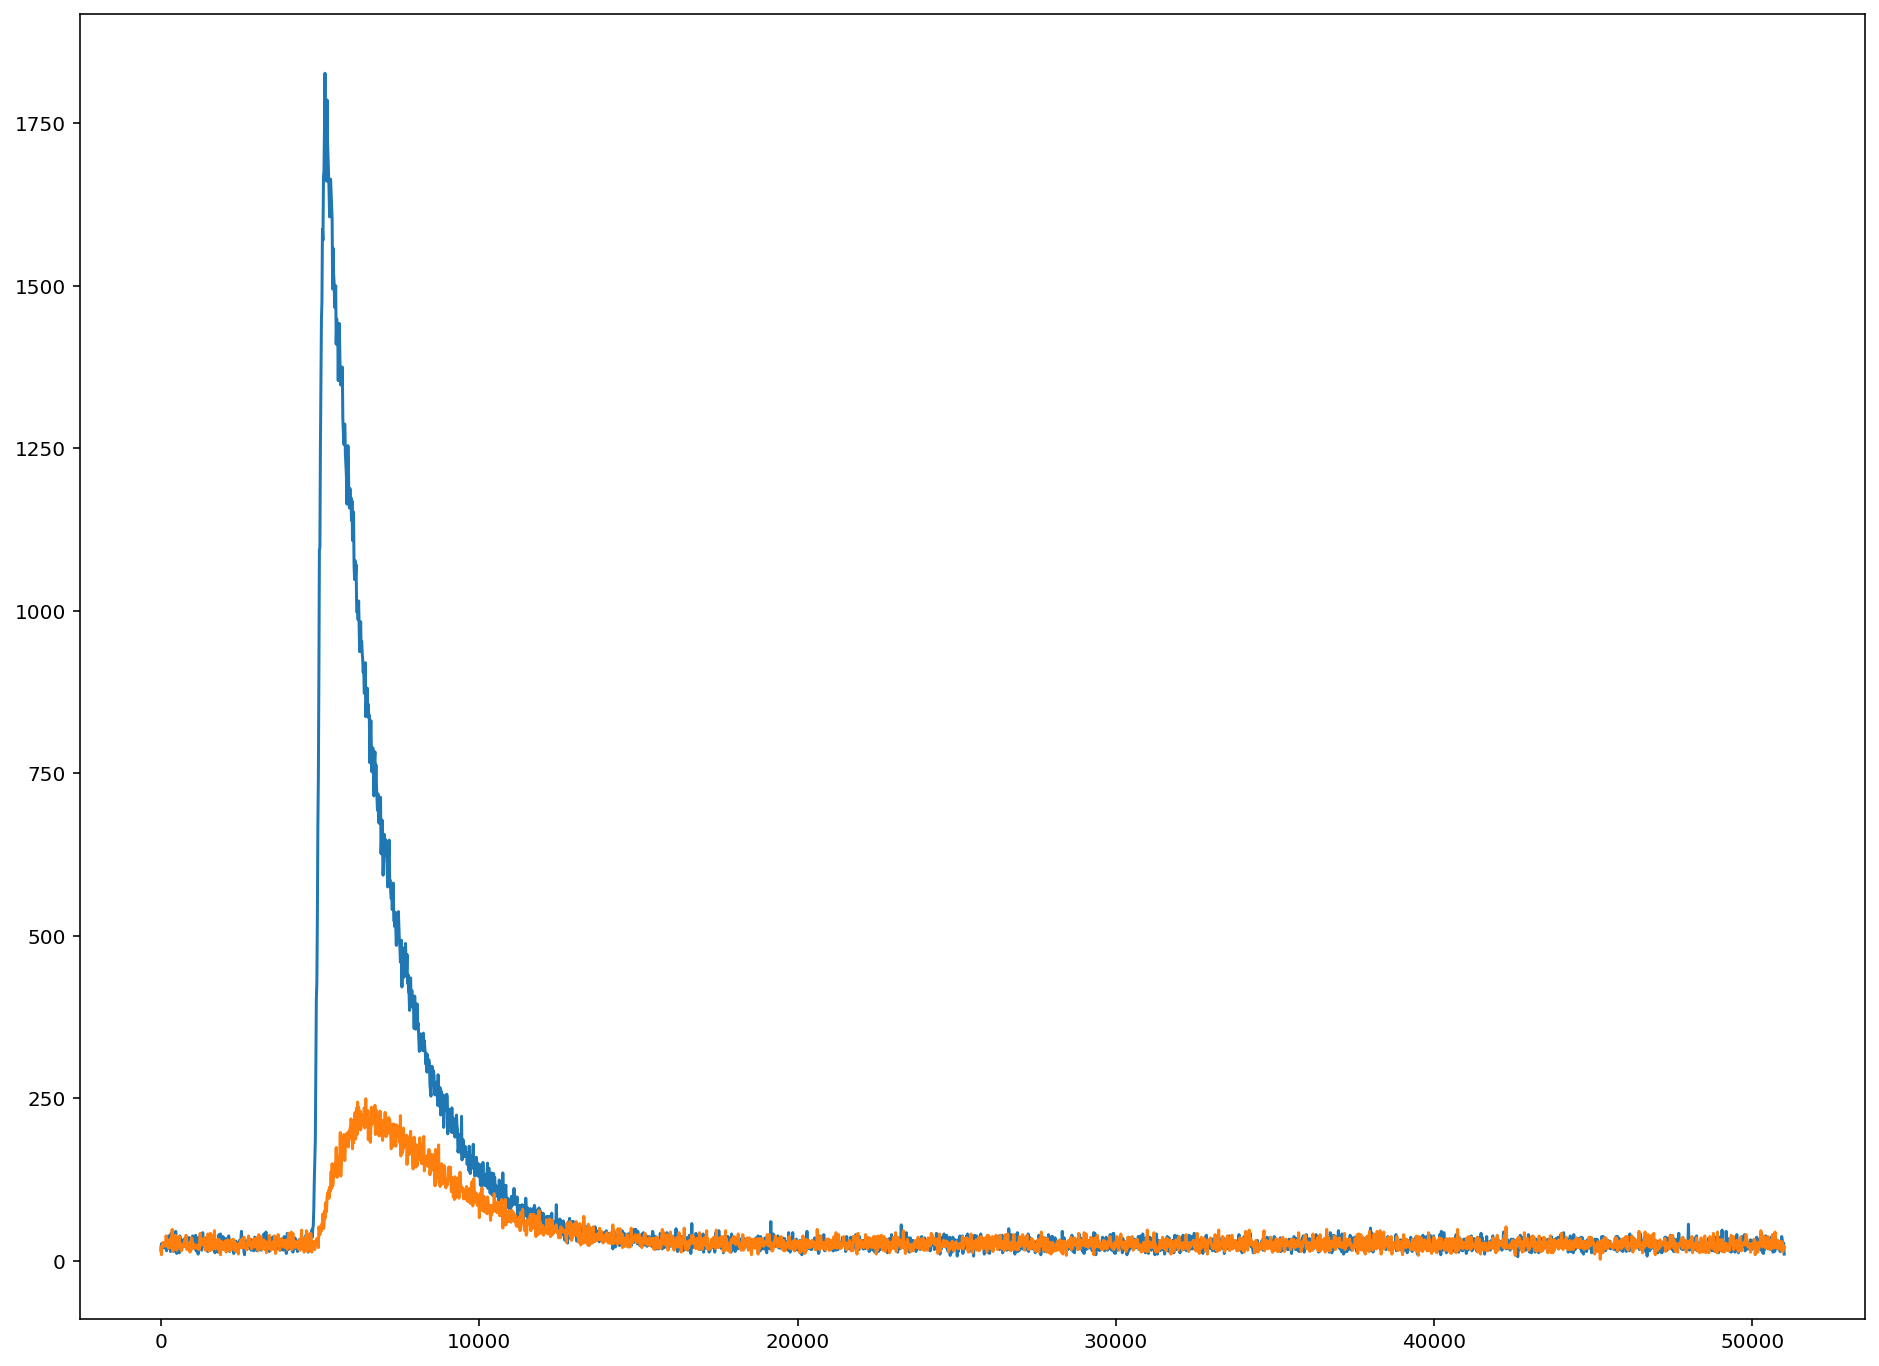

In [6]:
plt.plot(t, sim_data[:, 1])
plt.plot(t, sim_data[:, 3])

In [204]:
# Fitting 
fit = minimize(residuals, params, args = (t, sim_data, True), method = 'leastsq')

1.8103434381949706
1.8525535973214484


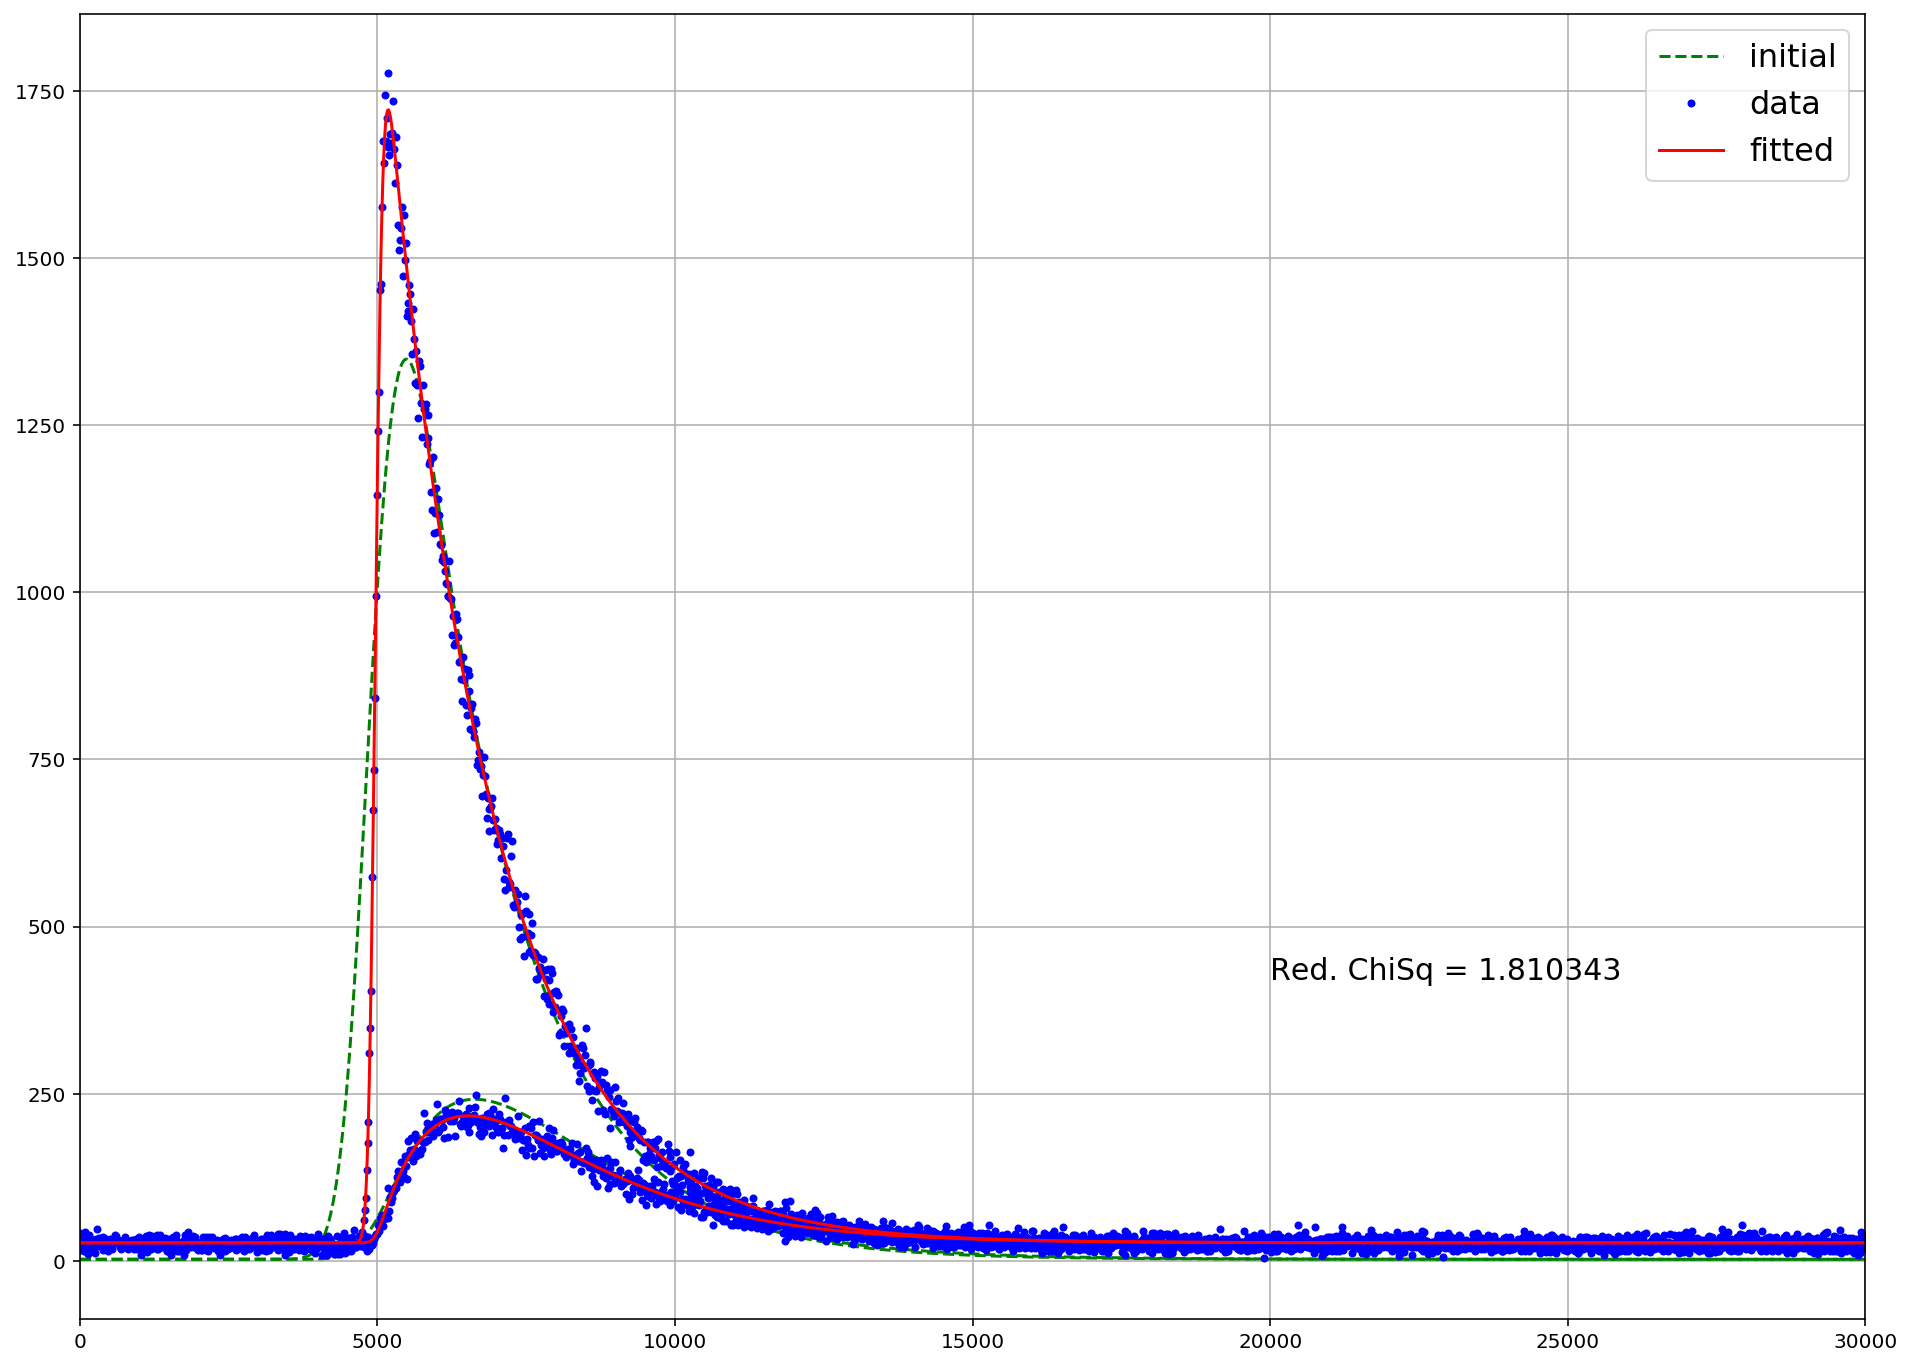

In [205]:
fit_params = [fit.params['kf_D'].value,
              fit.params['k_r'].value,
              fit.params['kf_A'].value,
              fit.params['sigma'].value,
              fit.params['mu'].value,
              fit.params['offset'].value]
initial_params = [params['kf_D'].value,
                  params['k_r'].value,
                  params['kf_A'].value,
                  params['sigma'].value,
                  params['mu'].value,
                  params['offset'].value]

#fitted = odeint(da_flim_ODE, y0_guess, t, hmax = dt, args = (fit_params, ))
#initial = odeint(da_flim_ODE, y0_guess, t, hmax = dt, args = (initial_params, ))
initial = eval_ode(y0, t, initial_params)
fitted = eval_ode(y0, t, fit_params)


# Manually calculating chi-squared
donor_resids = np.sum((sim_data[:, 1] - fitted[:, 1])**2 / fitted[:, 1])
redchi_D = donor_resids / (len(t) - len(fit_params) - 1)
print(redchi_D)
acceptor_resids = np.sum((sim_data[:, 3] - fitted[:, 3])**2 / fitted[:, 3])
redchi_A = acceptor_resids / (len(t) - len(fit_params) - 1)
print(redchi_A)

plt.plot(t, initial[:, 1], 'g--', label = 'initial')
plt.plot(t, initial[:, 3], 'g--')
plt.plot(t, sim_data[:, 1], 'b.', label = 'data')
plt.plot(t, sim_data[:, 3], 'b.')
plt.plot(t, fitted[:, 1], 'r-', label = 'fitted')
plt.plot(t, fitted[:, 3], 'r-')
plt.xlim(0, 30000)
plt.yscale('linear')
#plt.ylim(0, 700)
plt.grid()
plt.legend(loc = 'best')
plt.text(20000, 420, 'Red. ChiSq = %f' % redchi_D, fontsize = 15)
plt.show()

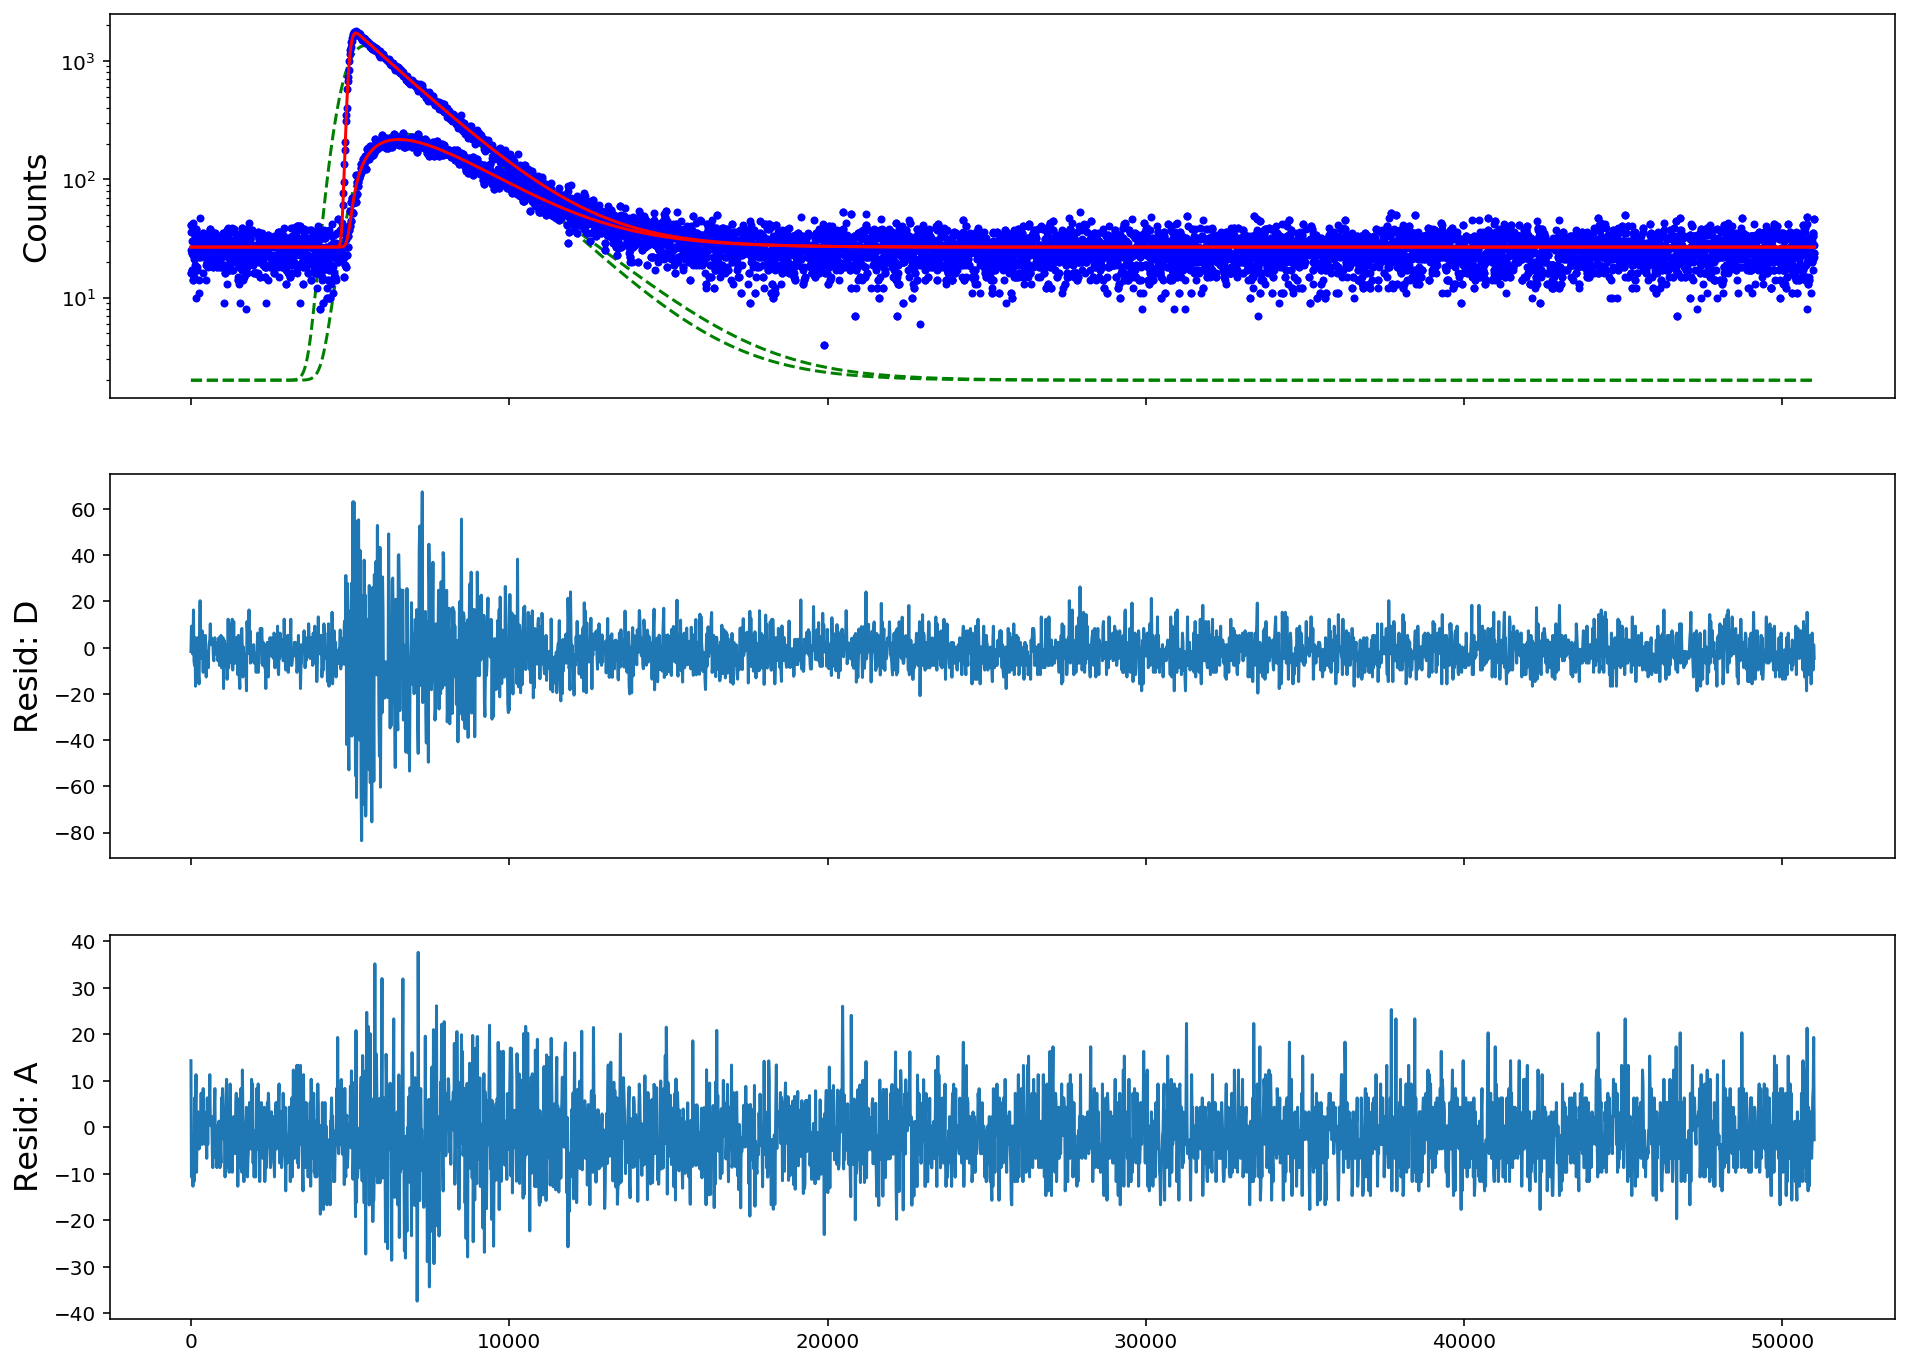

In [206]:
fig, ax = plt.subplots(3, 1, sharex = True)
ax[0].plot(t, initial[:, 1], 'g--', label = 'initial')
ax[0].plot(t, initial[:, 3], 'g--')
ax[0].plot(t, sim_data[:, 1], 'b.', label = 'data')
ax[0].plot(t, sim_data[:, 3], 'b.')
ax[0].plot(t, sim_data[:, 3], 'b.')
ax[0].plot(t, fitted[:, 1], 'r-', label = 'fitted')
ax[0].plot(t, fitted[:, 3], 'r-')
ax[0].set(yscale = 'log', ylabel = 'Counts')
ax[1].plot(t, (sim_data[:, 1] - fitted[:, 1]), '-')
ax[1].set(ylabel = 'Resid: D')
ax[2].plot(t, (sim_data[:, 3] - fitted[:, 3]), '-')
ax[2].set(ylabel = 'Resid: A')
plt.show()

In [207]:
print("kf_D: ", fit.params['kf_D'].value**-1, "\t ", sim_params[0]**-1)
print("k_r: ", fit.params['k_r'].value**-1, "\t ", sim_params[1]**-1)
print("kf_A: ", fit.params['kf_A'].value**-1, "\t ", sim_params[2]**-1)
print("sigma: ", fit.params['sigma'].value, "\t ", sim_params[3])
print("mu: ", fit.params['mu'].value, "\t \t ", sim_params[4])
print("offset: ", fit.params['offset'].value, "\t ", sim_params[5], noise)
print("D1: ", fit.params['D0'].value)
print("A1: ", fit.params['A0'].value)
print("*******")
print("Reduced Chi Squared: ", fit.redchi)
print("Minimizer Message: ", fit.message)
print("*******")



kf_D:  2534.994756162031 	  2500.0
k_r:  5822.318588099655 	  6000.0
kf_A:  1363.7989571921485 	  1400.0
sigma:  98.89712286640165 	  100.0
mu:  4998.81790449054 	 	  5000.0
offset:  26.696534532719753 	  0.0 25
D1:  2989.797550165022
A1:  1000.0000000000018
*******
Reduced Chi Squared:  9.620909127290721
Minimizer Message:  Fit succeeded. Could not estimate error-bars.
*******


In [7]:
## Fitting real data to Donor-Acceptor FRET-FLIM ODE
### Fitting fluorescence standard (no acceptor)

# Loading requires Python modules for the *whole* script!
import sys, struct, io, os
import math
from scipy.optimize import curve_fit
from scipy import optimize
import scipy.stats as stats
from scipy.integrate import odeint

# Redefining ptu reading FLIM array building script as function
def readPTU(path):
    
    ptureadstream = open(path, 'rb')

    # Reading file magic to check if file is PTU file, first 8 byte
    filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

    # Checking file valiidy by reading file magic and file version
    if(filemagic != 'PQTTTR'):
        print('%s is not a .ptu file!' % path)
        ptureadstream.close()
    else:
        print('%s is a valid .ptu file... Commencing.' % path)

    
    fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
    print('File Version: %s' % fileversion)

    # Definition of header tag types
    '''
    Each header piece begins with a tag type. It is checked and depending on the type,
    different data types have to be extracted.
    '''

    tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
    tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
    tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
    tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
    tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
    tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
    tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
    tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
    tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
    tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
    tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

    # Defining record types
    '''
    Record types of different PicoQuant TCSPC devices. Different TCSPC devices,
    require different modes of photon record retrieval. See PicoQuant
    documentary for further information. 
    Here, only rtHydraHarp2T3 data are considered.
    '''
    rtPicoHarpT3     = struct.unpack(">i", bytes.fromhex('00010303'))[0]
    rtPicoHarpT2     = struct.unpack(">i", bytes.fromhex('00010203'))[0]
    rtHydraHarpT3    = struct.unpack(">i", bytes.fromhex('00010304'))[0]
    rtHydraHarpT2    = struct.unpack(">i", bytes.fromhex('00010204'))[0]
    rtHydraHarp2T3   = struct.unpack(">i", bytes.fromhex('01010304'))[0]
    rtHydraHarp2T2   = struct.unpack(">i", bytes.fromhex('01010204'))[0]
    rtTimeHarp260NT3 = struct.unpack(">i", bytes.fromhex('00010305'))[0]
    rtTimeHarp260NT2 = struct.unpack(">i", bytes.fromhex('00010205'))[0]
    rtTimeHarp260PT3 = struct.unpack(">i", bytes.fromhex('00010306'))[0]
    rtTimeHarp260PT2 = struct.unpack(">i", bytes.fromhex('00010206'))[0]
    rtMultiHarpNT3   = struct.unpack(">i", bytes.fromhex('00010307'))[0]
    rtMultiHarpNT2   = struct.unpack(">i", bytes.fromhex('00010207'))[0]
    
    ## setting up header end string to terminate header decoding in while loop 
    headerend_tag = 'Header_End'
    reached_headerend = False


    # tuple that stores decoded information from header section
    header_contents = {}

    # decoding header
    while(reached_headerend == False):
        headerpiece = ptureadstream.read(48)
        tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
        tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
        tagType = struct.unpack('<i', headerpiece[36:40])[0]
        tagVal = headerpiece[40:48]

        if(tagId == headerend_tag):
            reached_headerend = True
            ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
            print('Found Header_End.')
            break

        if(tagType == tyEmpty8):
            header_contents['Empty'] =  'Empty'

        elif(tagType == tyBool8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyInt8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8):
            value = struct.unpack('<d', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8Array):
            value = struct.unpack("<q", tagVal)[0]
            print('Float array with %d entries' % value / 8)

        elif(tagType == tyAnsiString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('latin1').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyWideString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyBinaryBlob):
            value = struct.unpack("<q", tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyBitSet64):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyColor8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  "{0:#0{1}x}".format(value,18)

        elif(tagType == tyBinaryBlob):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyTDateTime):
            print(' ')

        else:
            continue
            #print('Unknown header tag type. Ignored.')
        
    
    headerend_bitoffset = ptureadstream.tell()
    
    FLIMInfo = {
    'Filename' : header_contents['$Filename'],
    'Comment': header_contents['$Comment'],
    'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
    'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
    'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
    'PixelsX' : header_contents['ImgHdr_PixX'],
    'PixelsY' : header_contents['ImgHdr_PixY'],
    'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
    'BaseResolution' : header_contents['HW_BaseResolution'],
    'Resolution' : header_contents['MeasDesc_Resolution'],
    'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
    'SyncRate' : header_contents['TTResult_SyncRate'],
    'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
    }
    
        ## Data type definition for recordarray
    ### Data types are chosen, so that they use the least space possible
    recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8),
                                  ('nanotime', np.float64), ('macrotime', np.float64)])


    # Preallocating array with decoded raw FLIM data
    recordarray = np.zeros(
            shape=FLIMInfo['NumberOfRecords'] - 1, dtype=recordBitType)

    # Factors required to recover real macro and nanotimes from raw photon data stream
    macroMultFactor = FLIMInfo['GlobalResolution']
    nanoMultFactor = FLIMInfo['Resolution'] * 1e9


    # Opening .ptu file and shoveling it into UInt32 section of preallocated array
    with open(path, 'rb') as file:
        file.seek(headerend_bitoffset)
        recordarray[:]['record'] = np.fromfile(file, dtype=np.uint32)
        file.close()

    # Recover marker signals and nanotimes of photon events
    recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
    recordarray[:]['nanotime'] = (np.right_shift(recordarray[:]['record'], 10) & 32767) * nanoMultFactor


    # Recover macrotimes and treat overflows
    recordarray = treatOverflows(recordarray, macroMultFactor)
    
    FLIMInfo['LinesInFile'] = countLines(recordarray)
    
    return(recordarray, FLIMInfo)


@jit(nopython=True)
def countLines(recordarray):
    '''
    Function: countLines(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    )
    
    - Counts number of line start (marker == 65) and line stop (marker == 66) events in raw photon data
    - Purpose: check data integrity
    '''

    numLinesStart = np.sum(recordarray['marker'] == 65)
    numLinesStop = np.sum(recordarray['marker'] == 66)
    
    if(numLinesStart != numLinesStop):
        print("Line start and stop numbers not equal. Corrupted file?")
    
    return numLinesStart


@jit(nopython=True, cache=True)
def treatOverflows(recordarray, macrotimefactor):
    '''
    Function treatOverflows(
    recordarray: 4 x numRec NumPy array holding raw 32 bit photon records in ['record']
    macrotimefactor: multiplication factor for mactotime clock to recover real experiment macrotime
    )
    Output is recordarray, but with populated ['macrotime'] row
    
    Takes whole record array and recovers real macrotime from raw photon TTTR data by adding
    number of macrotime clock overflows. See PicoQuant PTU documentary for further details and explanation.
    '''
    
    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor += overflow_period * \
                (record['record'] & (2**10 - 1))

        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10-1)) * macrotimefactor
            
    return(recordarray)

@jit(nopython=True, cache=True)
def buildFLIMArray(recordarray, channel, linesinfile, pixelsx, pixelsy, globRes, timeRes, spatialBinning, temporalBinning):
    '''
    buildFLIMArray(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    - channel: int; which channel to reconstruct the flimarray from
    - pixelsx: original image dimension in X, stored in FLIMInfo
    - pixelsy: original image dimension in Y, stored in FLIMInfo
    - globRes: global measurment of nanotime, stored in FLIMInfo, in ns, 51 ns for 20 MHz laser pulse frequency
    - timeRes: nanotime resolution of TCSPC device, in ps
    - spatialBinning: user-defined binning factor of image, calculated as 2**factor
    - temporalBinning: user-defined binning factor for fluorescence decay histogram
    )
    '''

    eventCounter = 0  # Keeps track of photon / marker events while looping through data
    lineCounter = 0  # Stores current scan line numbers
    frameCounter = 0  # Stores current frame number
    # How many frames are in the image; assume square format
    framesInFile = linesinfile / pixelsx
    # Number of TCSPC bins based on time between pulses and TCSPC time resolution
    decayBins = math.ceil((globRes / timeRes)/(2**temporalBinning))
    globalResolution = globRes * 10E8  # time between pulses in ns
    timeResolution = timeRes * 10E9  # TCSPC time resolution in ns

    binningFactor = 2**spatialBinning

    lineStart = 0
    lineStop = 0
    pixelTime = 0  # Tmp variable for storing time/pixel when line start and stop macro times are determined; needed to assign photons to y pixels in a line

    # Set to True when last scan line was evaluated and frameCounter >= framesInFile
    lastLine = False
    # Set to True when line start marker is found (= 65), starts photon assignments to y-pixels in a line (x); set to False when line stop marker is found (=66)
    lineActive = False

    # List storing photon macrotimes when line is active to determine y-pixel position of photon
    tmpEvents = [np.float64(x) for x in range(0)]
    # List storing photon nanotimes to assign to 3D-FLIM array in x-y position
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0  # Holds marker value for one loop iteration
    tmpMacro = 0  # Holds macrotime value for one loop iteration
    tmpNanotime = 0  # Holds nanotime value for one loop iteration
    diff = 0  # Stores difference between photon macro time and line start to determine photon y-position
    # Count out-of-range photons (photons with macrotime below or above line time difference)
    oorPhotons = 0

    nPixelX = int(pixelsx / binningFactor)
    nPixelY = int(pixelsy / binningFactor)

    pixelIDX = 0  # Current x position in image
    pixelIDY = 0  # Current y position in image

    flimarray = np.zeros((nPixelX, nPixelY, decayBins), dtype=np.uint16)
    # 2D array for intensity image
    intensityImage = np.zeros((nPixelX, nPixelY), dtype=np.uint16)

    while(lastLine == False):
        tmpMarker = recordarray['marker'][eventCounter]

        if(tmpMarker == 65):  # Event is line start marker
            lineActive = True  # Starting line evaluation (next while loop)
            # Store line start time
            lineStart = recordarray['macrotime'][eventCounter]
            eventCounter += 1
            continue  # Skip this loop iteration

        while(lineActive == True):
            tmpMarker = recordarray['marker'][eventCounter]
            tmpMacro = recordarray['macrotime'][eventCounter]
            tmpNanotime = recordarray['nanotime'][eventCounter]

            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / (nPixelY)

                # Build intensity image and FLIM array from photon macro times
                for i in range(0, len(tmpEvents)):
                    diff = tmpEvents[i] - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    binID = math.floor((tmpNano[i]/globalResolution)*decayBins) - 1

                    if(pixelIDY < 0 or pixelIDY > (nPixelY - 1)):
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (nPixelY - 1)):
                            pixelIDY = nPixelY - 1

                    intensityImage[math.floor(pixelIDX)][pixelIDY] += 1
                    flimarray[math.floor(pixelIDX)][pixelIDY][binID] += 1

                pixelIDX = pixelIDX + (1/binningFactor)
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]

            eventCounter += 1

        if(lineCounter > (pixelsx - 1)):
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0

        if(frameCounter >= framesInFile):
            lastLine = True

        eventCounter += 1
        
    return flimarray, intensityImage


In [8]:
## Loading fluoresceine data
fluoresceine_raw = readPTU('../notebooks/data/TK-E-R51_CMV-mCh-R54_120minNCS_7_1.ptu')

fluoresceine_c1, fluoresceine_c1_intImg = buildFLIMArray(fluoresceine_raw[0],
                                    channel = 0, 
                                    linesinfile = fluoresceine_raw[1]['LinesInFile'],
                                    pixelsx = fluoresceine_raw[1]['PixelsX'],
                                    pixelsy = fluoresceine_raw[1]['PixelsY'],
                                    globRes = fluoresceine_raw[1]['GlobalResolution'],
                                    timeRes = fluoresceine_raw[1]['Resolution'],
                                    spatialBinning = 3,
                                    temporalBinning = 0)
fluoresceine_c2, fluoresceine_c2_intImg = buildFLIMArray(fluoresceine_raw[0],
                                    channel = 1, 
                                    linesinfile = fluoresceine_raw[1]['LinesInFile'],
                                    pixelsx = fluoresceine_raw[1]['PixelsX'],
                                    pixelsy = fluoresceine_raw[1]['PixelsY'],
                                    globRes = fluoresceine_raw[1]['GlobalResolution'],
                                    timeRes = fluoresceine_raw[1]['Resolution'],
                                    spatialBinning = 3,
                                    temporalBinning = 0)

../notebooks/data/TK-E-R51_CMV-mCh-R54_120minNCS_7_1.ptu is a valid .ptu file... Commencing.
File Version: 1.0.00
 
Found Header_End.


In [9]:
# Overall decay over the whole image
fluoresceine_c1_sumDecay = np.sum(np.sum(fluoresceine_c1, axis=0), axis=0)
fluoresceine_c2_sumDecay = np.sum(np.sum(fluoresceine_c2, axis=0), axis=0)

# Generating time axis from TCSPC data
tEnd = fluoresceine_raw[1]['GlobalResolution'] * 1e12
dt = fluoresceine_raw[1]['Resolution'] * 1e12
numBins = math.ceil((tEnd/dt))
tAxis = np.linspace(0, tEnd, numBins)
print(numBins)

3214


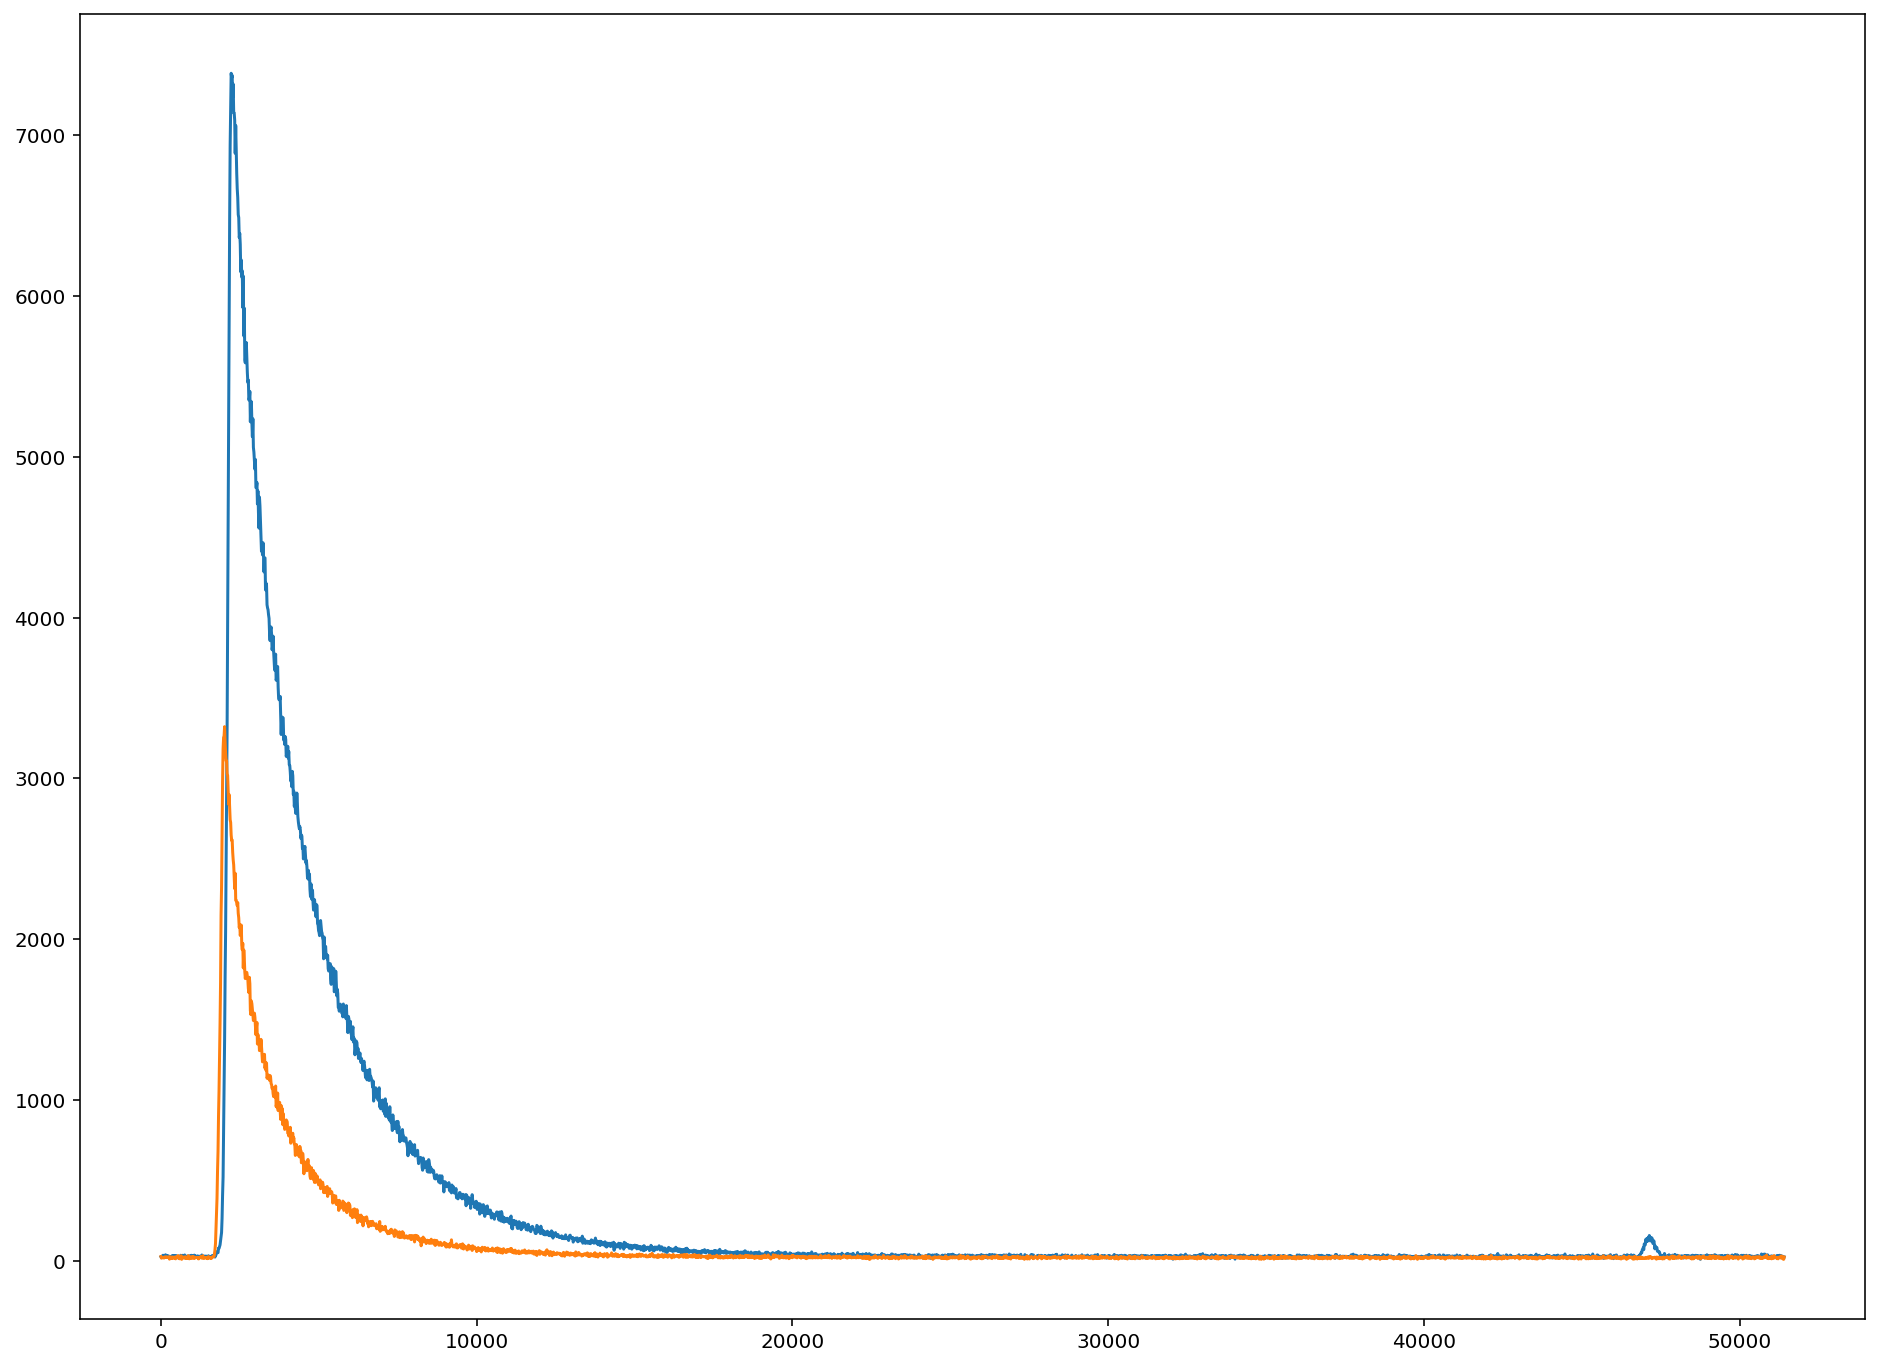

In [10]:
# Plotting overall decay
plt.plot(tAxis, fluoresceine_c1_sumDecay)
plt.plot(tAxis, fluoresceine_c2_sumDecay)
plt.show()

In [277]:
# Guessed parameters for fitting
params = Parameters()
params.add('D0', value = 50000, min = 100, max = 250000)
params.add('A0', value = 50000, min = 0, max = 250000)
params.add('D1', value = 0, min = 0, max = 1)
params.add('A1', value = 0, min = 0, max = 1)
params.add('kf_D', value = 1/3600, min = 1/3000, max = 1/4000)
params.add('k_r', value = 1/2000, min = 1/1000, max = 1/10000)
params.add('kf_A', value = 1/3000, min = 1/1000, max = 1/3500)
params.add('sigma', value = 80, min = 20, max = 500)
params.add('mu', value = 1500, min = 500, max = 5000)
params.add('offset', value = 50, min = 1, max = 500)

fake_A_axis = np.zeros(len(tAxis))

data = np.array((fake_A_axis, fluoresceine_c1_sumDecay, fake_A_axis, fluoresceine_c2_sumDecay))
data = data.transpose()
print(data.shape)

(3214, 4)


In [278]:
fit = minimize(residuals, params, args = (tAxis, data, True), method = 'leastsq')

KeyboardInterrupt: 

In [ ]:
fit_params = [fit.params['kf_D'].value,
              fit.params['k_r'].value,
              fit.params['kf_A'].value,
              fit.params['sigma'].value,
              fit.params['mu'].value,
              fit.params['offset'].value]

y0 = [fit.params['D0'], fit.params['D1'], fit.params['A0'],fit.params['A1']]

fitted = eval_ode(y0, tAxis, fit_params)


# Manually calculating chi-squared
donor_resids = np.sum((data[:, 1] - fitted[:, 1])**2 / fitted[:, 1])
redchi_D = donor_resids / (len(t) - len(fit_params) - 1)
print(redchi_D)

plt.plot(tAxis, data[:, 1], 'b.', label = 'data')
plt.plot(tAxis, fitted[:, 1], 'r-', label = 'fitted')
plt.yscale('linear')
plt.grid()
plt.legend(loc = 'best')
plt.text(20000, max(fitted[:, 1])*0.5, 'Red. ChiSq = %f' % redchi_D, fontsize = 15)
plt.show()

In [ ]:
print("kf_D: ", fit.params['kf_D'].value**-1)
print("k_r: ", fit.params['k_r'].value**-1)
print("kf_A: ", fit.params['kf_A'].value**-1)
print("sigma: ", fit.params['sigma'].value)
print("mu: ", fit.params['mu'].value)
print("offset: ", fit.params['offset'].value)
print("D1: ", fit.params['D0'].value)
print("A1: ", fit.params['A0'].value)
print("*******")
print("Reduced Chi Squared: ", fit.redchi)
print("Minimizer Message: ", fit.message)
print("*******")




In [ ]:
plt.plot(tAxis, (fitted[:, 1] - data[:, 1]))
plt.plot(tAxis, (fitted[:, 3] - data[:, 3]))
plt.show()